In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Vol Reduction Strategy

- Use VIX to estimate volatility of underlying
- Reduce position size when forward volatility is high

## Libraries

In [39]:
import pandas as pd
import numpy as np
from utils.backtester import BackTester
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from utils.data_fetcher import YahooDataFetcher
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import lightgbm as lgb
import optuna
from indicators.returns import calculate_binary_forward_returns, calculate_binary_returns, calculate_binary_MA_returns, calculate_forward_returns, calculate_returns, calculate_MA_returns
from indicators.breakout import calculate_breakout
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.volume import calculate_rel_volume
from indicators.trend import calculate_r2

## Data Loading

In [40]:
# Current date
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")
print(current_date)
current_date = "20250321"

# # Fetch daily price data from Yahoo Finance
# fetcher = YahooDataFetcher()
# ticker_list = ['SPY', '^VIX']
# fetcher.load_price_data(tickers=ticker_list)

ticker = "SPY"
df_raw = pd.read_pickle(f'data/raw/price/{ticker}_{current_date}.pkl') 

df_data = df_raw.copy()
df_data['returns'] = df_data['close'].pct_change()
df_vix = pd.read_pickle('./data/raw/price/^VIX_20250321.pkl')
df_data['vol_forward'] = calculate_forward_vol(df_data, 21)
df_data['vix'] = df_vix['close']
df_data.dropna(inplace=True)

df_data[['vol_forward']].describe()

20250330


,vol_forward
count,8070.000000
mean,0.155441
std,0.096845
min,0.033958
25%,0.095082
50%,0.131623
75%,0.188975
max,0.922183


## Time Series Split

In [41]:
n_splits = 10
data = []
split = TimeSeriesSplit(n_splits=n_splits)
for train_index, test_index in split.split(df_data):
    print("TRAIN:", train_index, "TEST:", test_index)
    df_train, df_test = df_data.iloc[train_index], df_data.iloc[test_index]
    

    data.append({
        'train': df_train,
        'test': df_test,
        'train_dates': (df_train.index[0], df_train.index[-1]),
        'test_dates': (df_test.index[0], df_test.index[-1]),
    })

# data

TRAIN: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244

## Forecast Forward Vol with VIX

We use a linear model to convert VIX to a forward vol estimate.

In [42]:
for i in range(n_splits):
    X_train = data[i]['train']['vix'].to_numpy().reshape(-1, 1)
    y_train = data[i]['train']['vol_forward'].to_numpy()

    X_test = data[i]['test']['vix'].to_numpy().reshape(-1, 1)
    y_test = data[i]['test']['vol_forward'].to_numpy()

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    data[i]['test']['vol_forward_pred'] = y_pred
    y_pred = model.predict(X_train)
    data[i]['train']['vol_forward_pred'] = y_pred



C:\Users\alexr\AppData\Local\Temp\ipykernel_3112\2651569143.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[i]['test']['vol_forward_pred'] = y_pred
C:\Users\alexr\AppData\Local\Temp\ipykernel_3112\2651569143.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[i]['train']['vol_forward_pred'] = y_pred
C:\Users\alexr\AppData\Local\Temp\ipykernel_3112\2651569143.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

## Strategy

In [43]:
import backtrader as bt
from strategies.base import BaseStrategy

class VolReductionTrendStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('lookback_period', 252),
        ('rebalance_period', 21),  # Rebalance period in days
        
        ('df_vol', pd.DataFrame()),
        ('vol_threshold_1', 0.05),
        ('vol_threshold_2', 0.1),
    )

    def __init__(self):
        super().__init__()
        
        # Indicator to track the trend via lagged returns
        self.returns = bt.indicators.PercentChange(self.data.close, period=self.p.lookback_period)

        # Rebalance period
        self.rebalance_day = 0

        # Forward vol prediction
        self.df_vol = self.p.df_vol

        
    def next(self):
        super().next()

        # On rebalance day, calculate the target position and submit the order
        if self.rebalance_day % self.p.rebalance_period == 0:
            target_position = self.calculate_position() * (self.broker.getvalue() / self.data.close[0])
            current_position = self.getposition(self.data).size
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1

    
    def calculate_position(self):
        # Get current forward volatility prediction
        current_date = self.datetime.date()
        volatility = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), 'vol_forward_pred'].values[0]
        target_position = 0
        if self.returns[0] > 0:
            target_position = 1
        else:
            target_position = -1
        

        # if volatility > threshold, reduce position size
        multiplier = 1.0
        if volatility > self.p.vol_threshold_1:
            multiplier = 0.5
        elif volatility > self.p.vol_threshold_2:
            multiplier = 0.0
        
        # multiplier = self.p.vol_slope * volatility + self.p.vol_intercept
        # multiplier = np.clip(multiplier, 0.0, 1.0)
        target_position *= multiplier
        
        return target_position


## Optuna Optimization

  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-03-30 22:52:23,770] A new study created in memory with name: no-name-63897131-3c74-45ad-9ba7-b9dc0c759179


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 22:52:24,114] Trial 0 finished with value: 0.002161138887307068 and parameters: {'vol_threshold_1': 0.16497130028707097, 'vol_threshold_2': 0.5545420709884354}. Best is trial 0 with value: 0.002161138887307068.
[I 2025-03-30 22:52:24,116] Trial 1 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.6138351891235391, 'vol_threshold_2': 0.08725807584659284}. Best is trial 0 with value: 0.002161138887307068.
[I 2025-03-30 22:52:24,433] Trial 2 finished with value: 0.002161138887307068 and parameters: {'vol_threshold_1': 0.17300514639860776, 'vol_threshold_2': 0.22132124727763292}. Best is trial 0 with value: 0.002161138887307068.
[I 2025-03-30 22:52:24,757] Trial 3 finished with value: 0.002161138887307068 and parameters: {'vol_threshold_1': 0.5891199618164317, 'vol_threshold_2': 0.7353391728151988}. Best is trial 0 with value: 0.002161138887307068.
[I 2025-03-30 22:52:25,078] Trial 4 finished with value: 0.002161138887307068 and parameters: {'vol_threshold_1': 0.

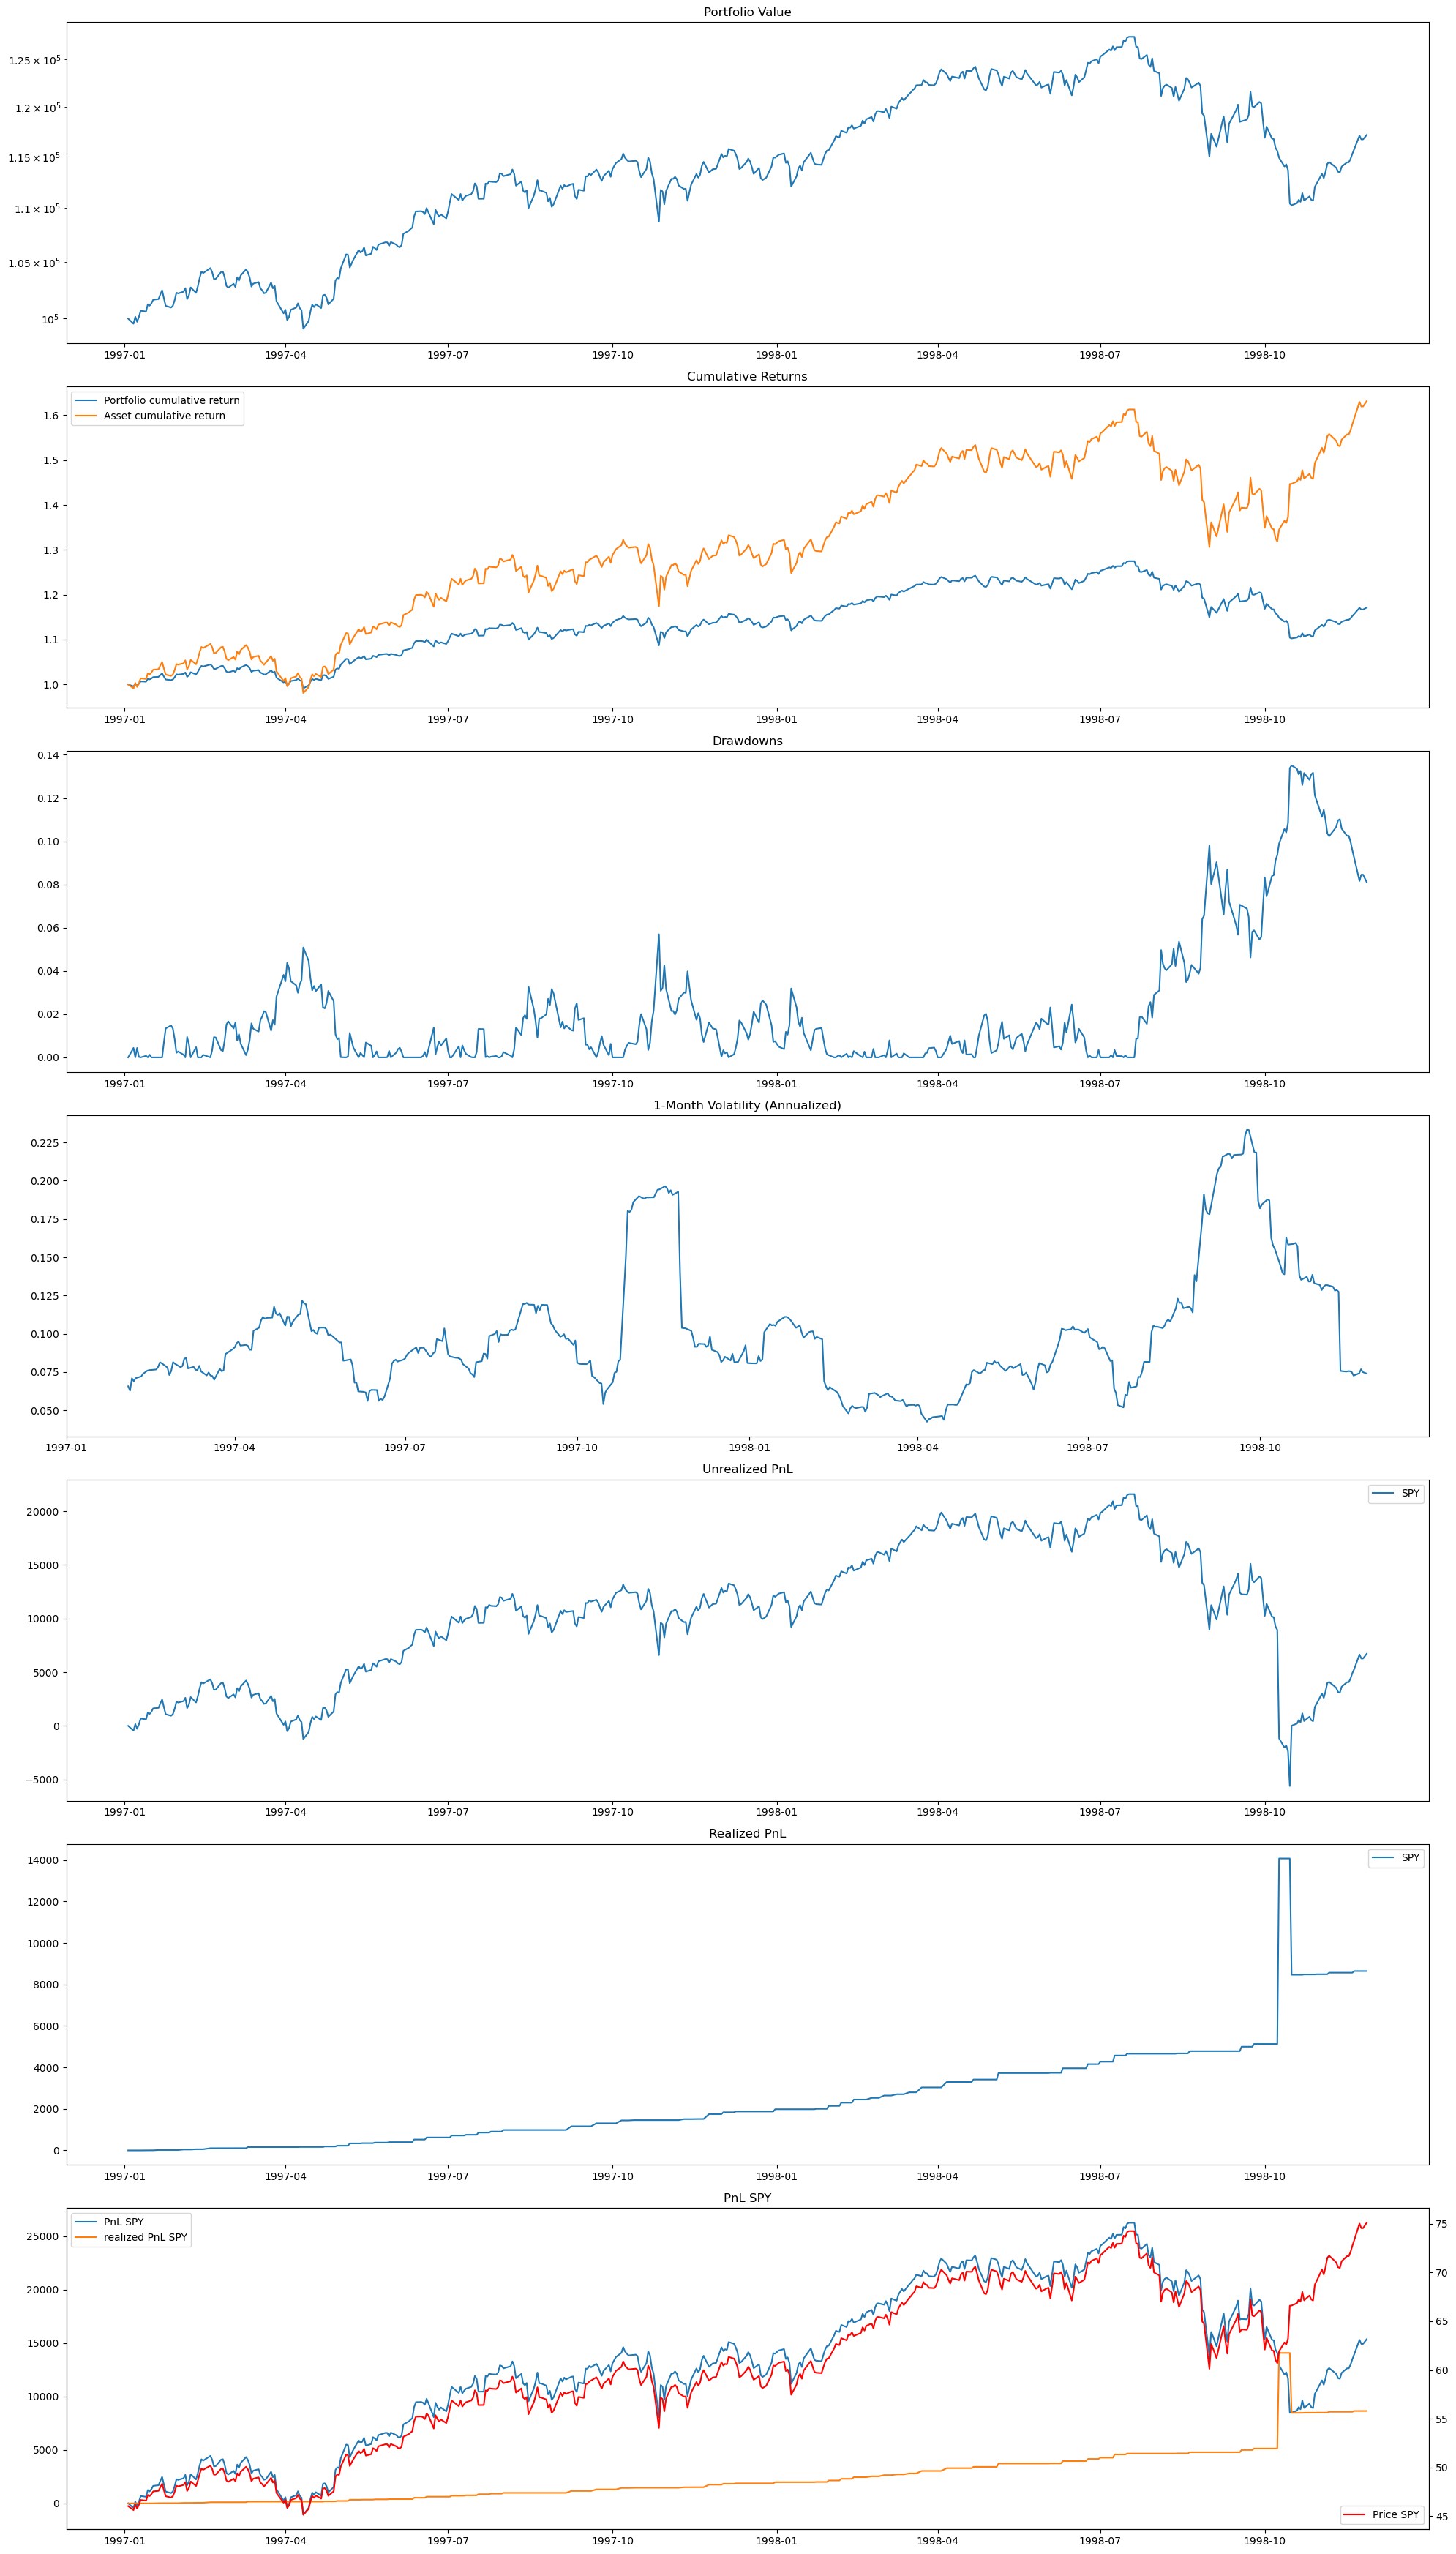

[I 2025-03-30 22:52:56,041] A new study created in memory with name: no-name-55d58027-d2e6-4e7e-b783-9e0d490b529a


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 22:52:56,799] Trial 0 finished with value: 0.0577978839638964 and parameters: {'vol_threshold_1': 0.015099163676288163, 'vol_threshold_2': 0.9328038660748316}. Best is trial 0 with value: 0.0577978839638964.
[I 2025-03-30 22:52:57,524] Trial 1 finished with value: 0.12074407693395695 and parameters: {'vol_threshold_1': 0.21618639650676263, 'vol_threshold_2': 0.7729673150473891}. Best is trial 1 with value: 0.12074407693395695.
[I 2025-03-30 22:52:58,262] Trial 2 finished with value: 0.0693937745891442 and parameters: {'vol_threshold_1': 0.1216351265353155, 'vol_threshold_2': 0.6080897849510523}. Best is trial 1 with value: 0.12074407693395695.
[I 2025-03-30 22:52:58,265] Trial 3 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.7177451469140066, 'vol_threshold_2': 0.4242172756634841}. Best is trial 1 with value: 0.12074407693395695.
[I 2025-03-30 22:52:58,973] Trial 4 finished with value: 0.09411116542573139 and parameters: {'vol_threshold_1': 0.150386700337

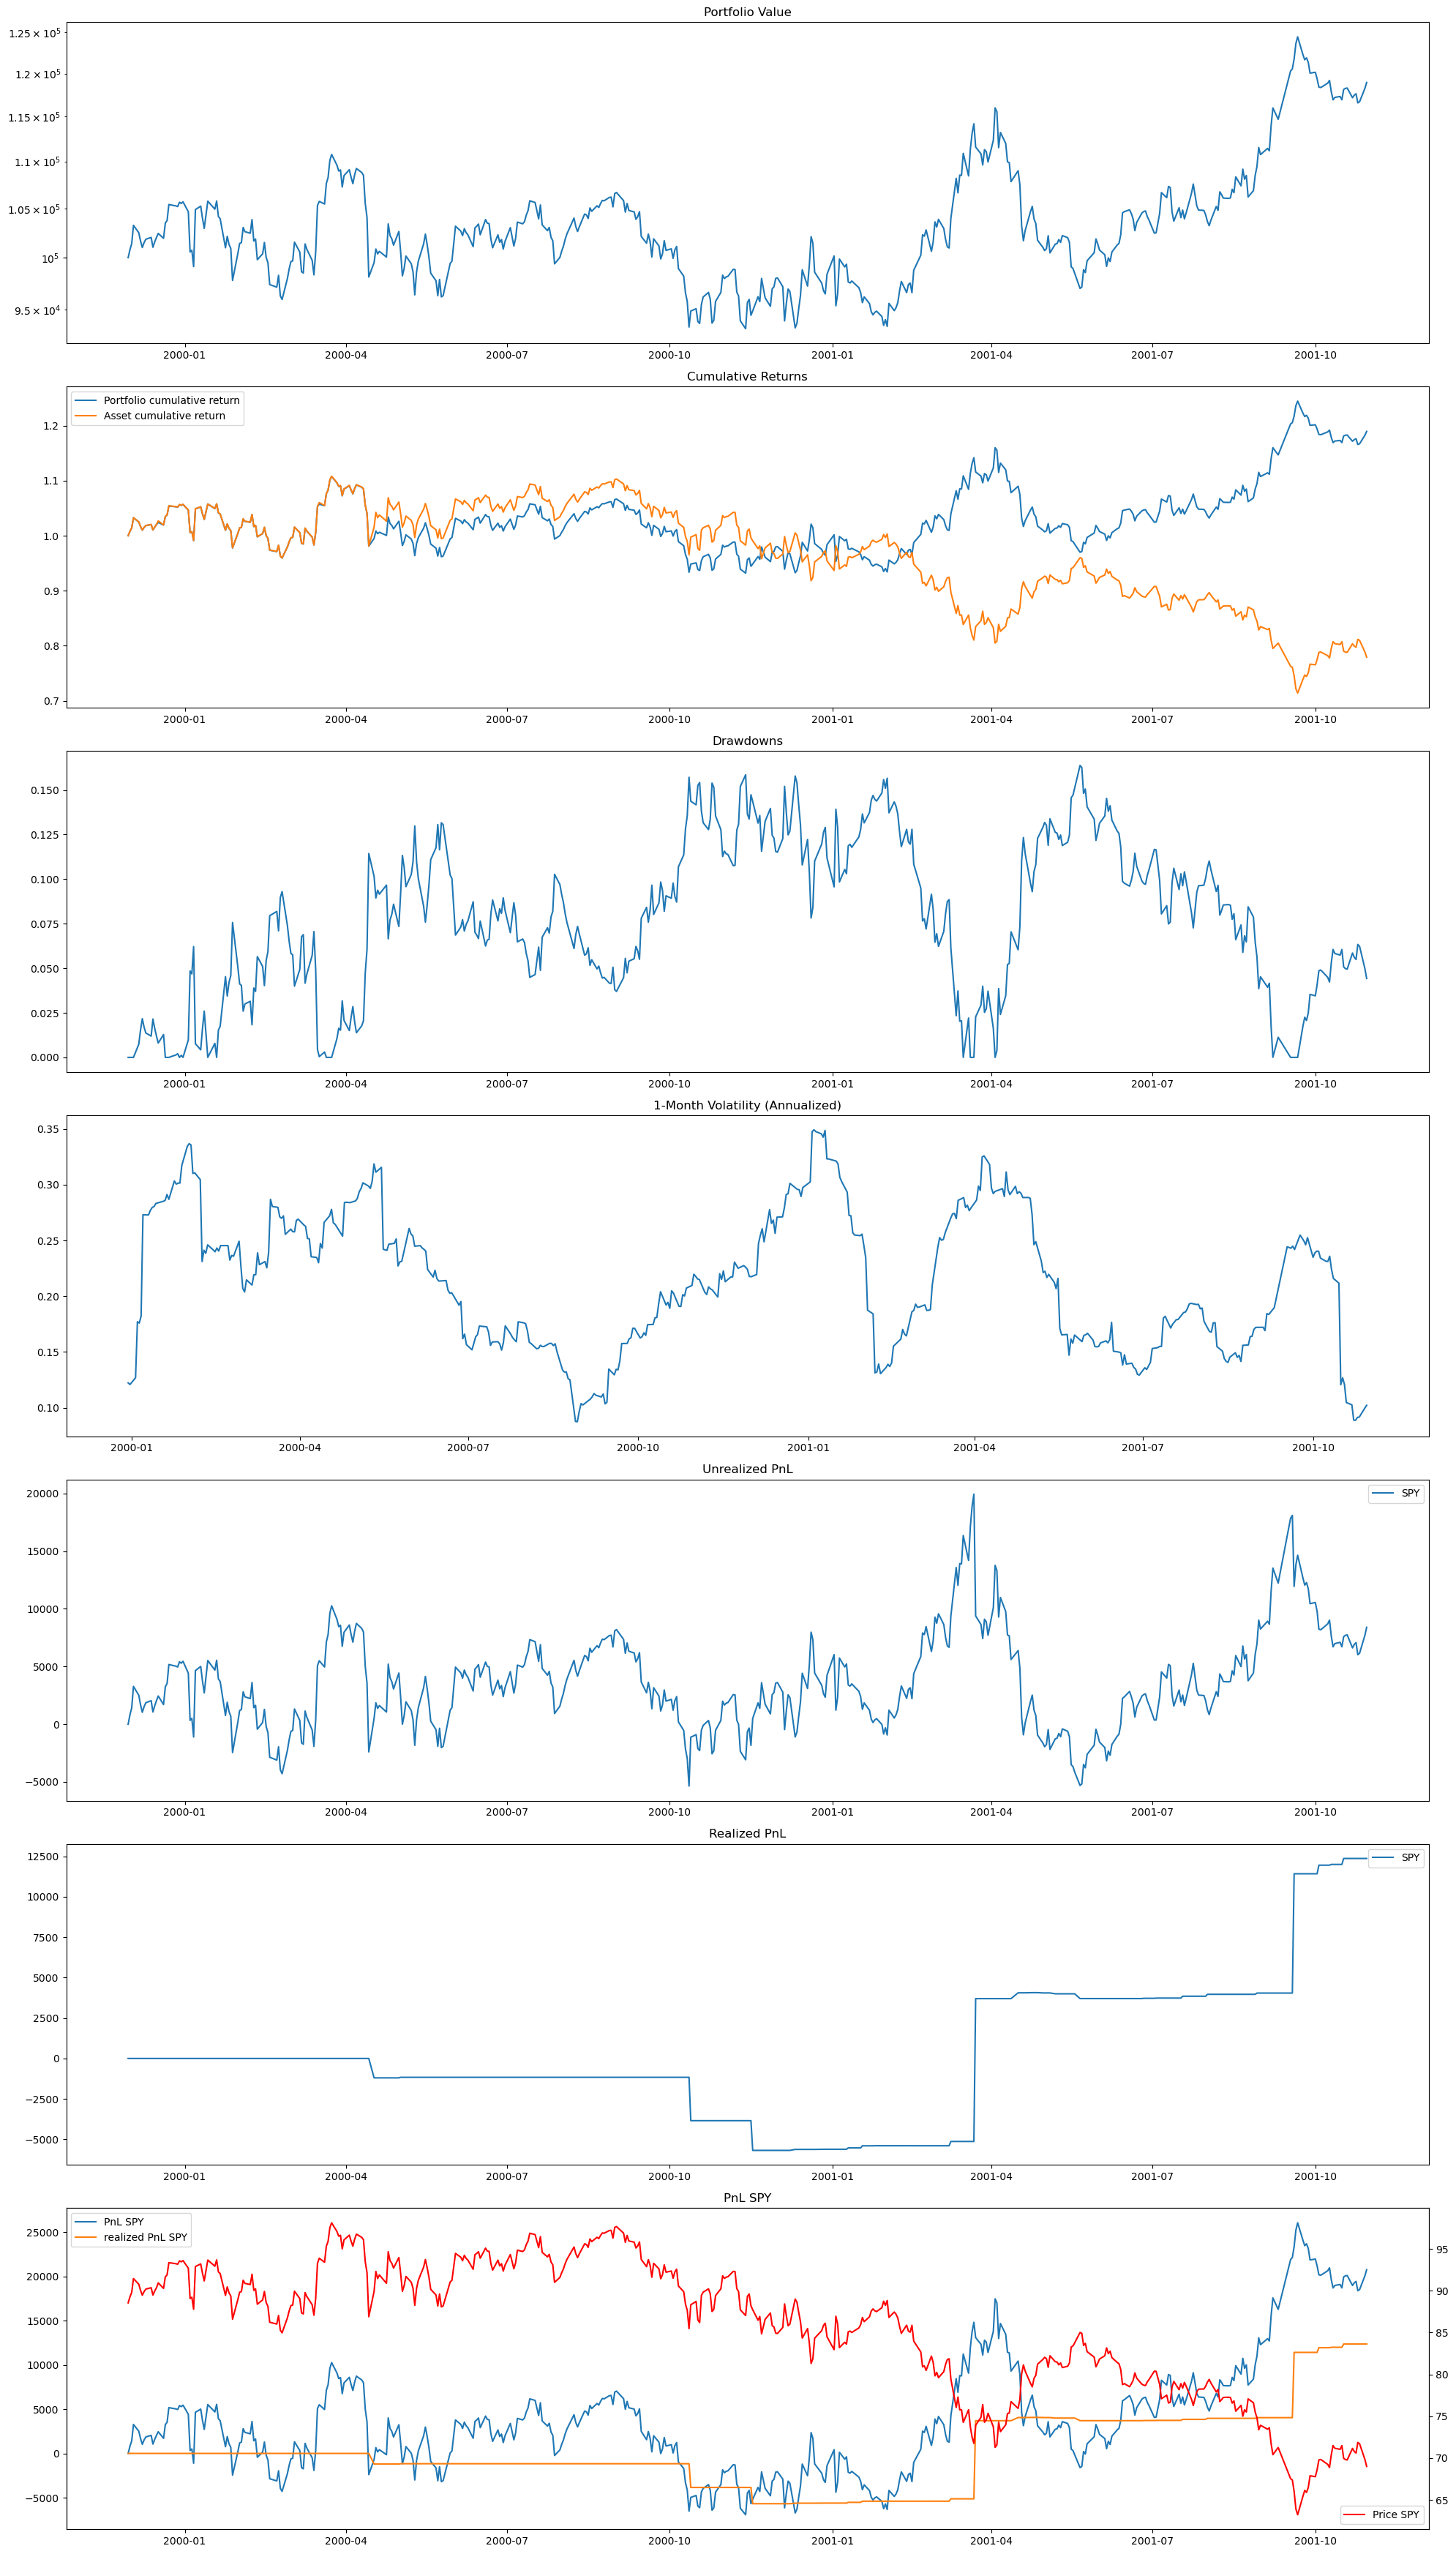

[I 2025-03-30 22:54:08,196] A new study created in memory with name: no-name-b4238481-95cf-496a-b9ac-61edae7682ba


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 22:54:09,369] Trial 0 finished with value: 0.06948244867012887 and parameters: {'vol_threshold_1': 0.11481227876679745, 'vol_threshold_2': 0.9717288667718124}. Best is trial 0 with value: 0.06948244867012887.
[I 2025-03-30 22:54:10,518] Trial 1 finished with value: 0.06182309447657808 and parameters: {'vol_threshold_1': 0.01965575871215519, 'vol_threshold_2': 0.9051957139740696}. Best is trial 0 with value: 0.06948244867012887.
[I 2025-03-30 22:54:10,520] Trial 2 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.8565952641122798, 'vol_threshold_2': 0.409754939347168}. Best is trial 0 with value: 0.06948244867012887.
[I 2025-03-30 22:54:10,521] Trial 3 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.9495236928430587, 'vol_threshold_2': 0.5108014716986885}. Best is trial 0 with value: 0.06948244867012887.
[I 2025-03-30 22:54:11,661] Trial 4 finished with value: 0.12001171345723405 and parameters: {'vol_threshold_1': 0.3891853115326356, 'vol_thr

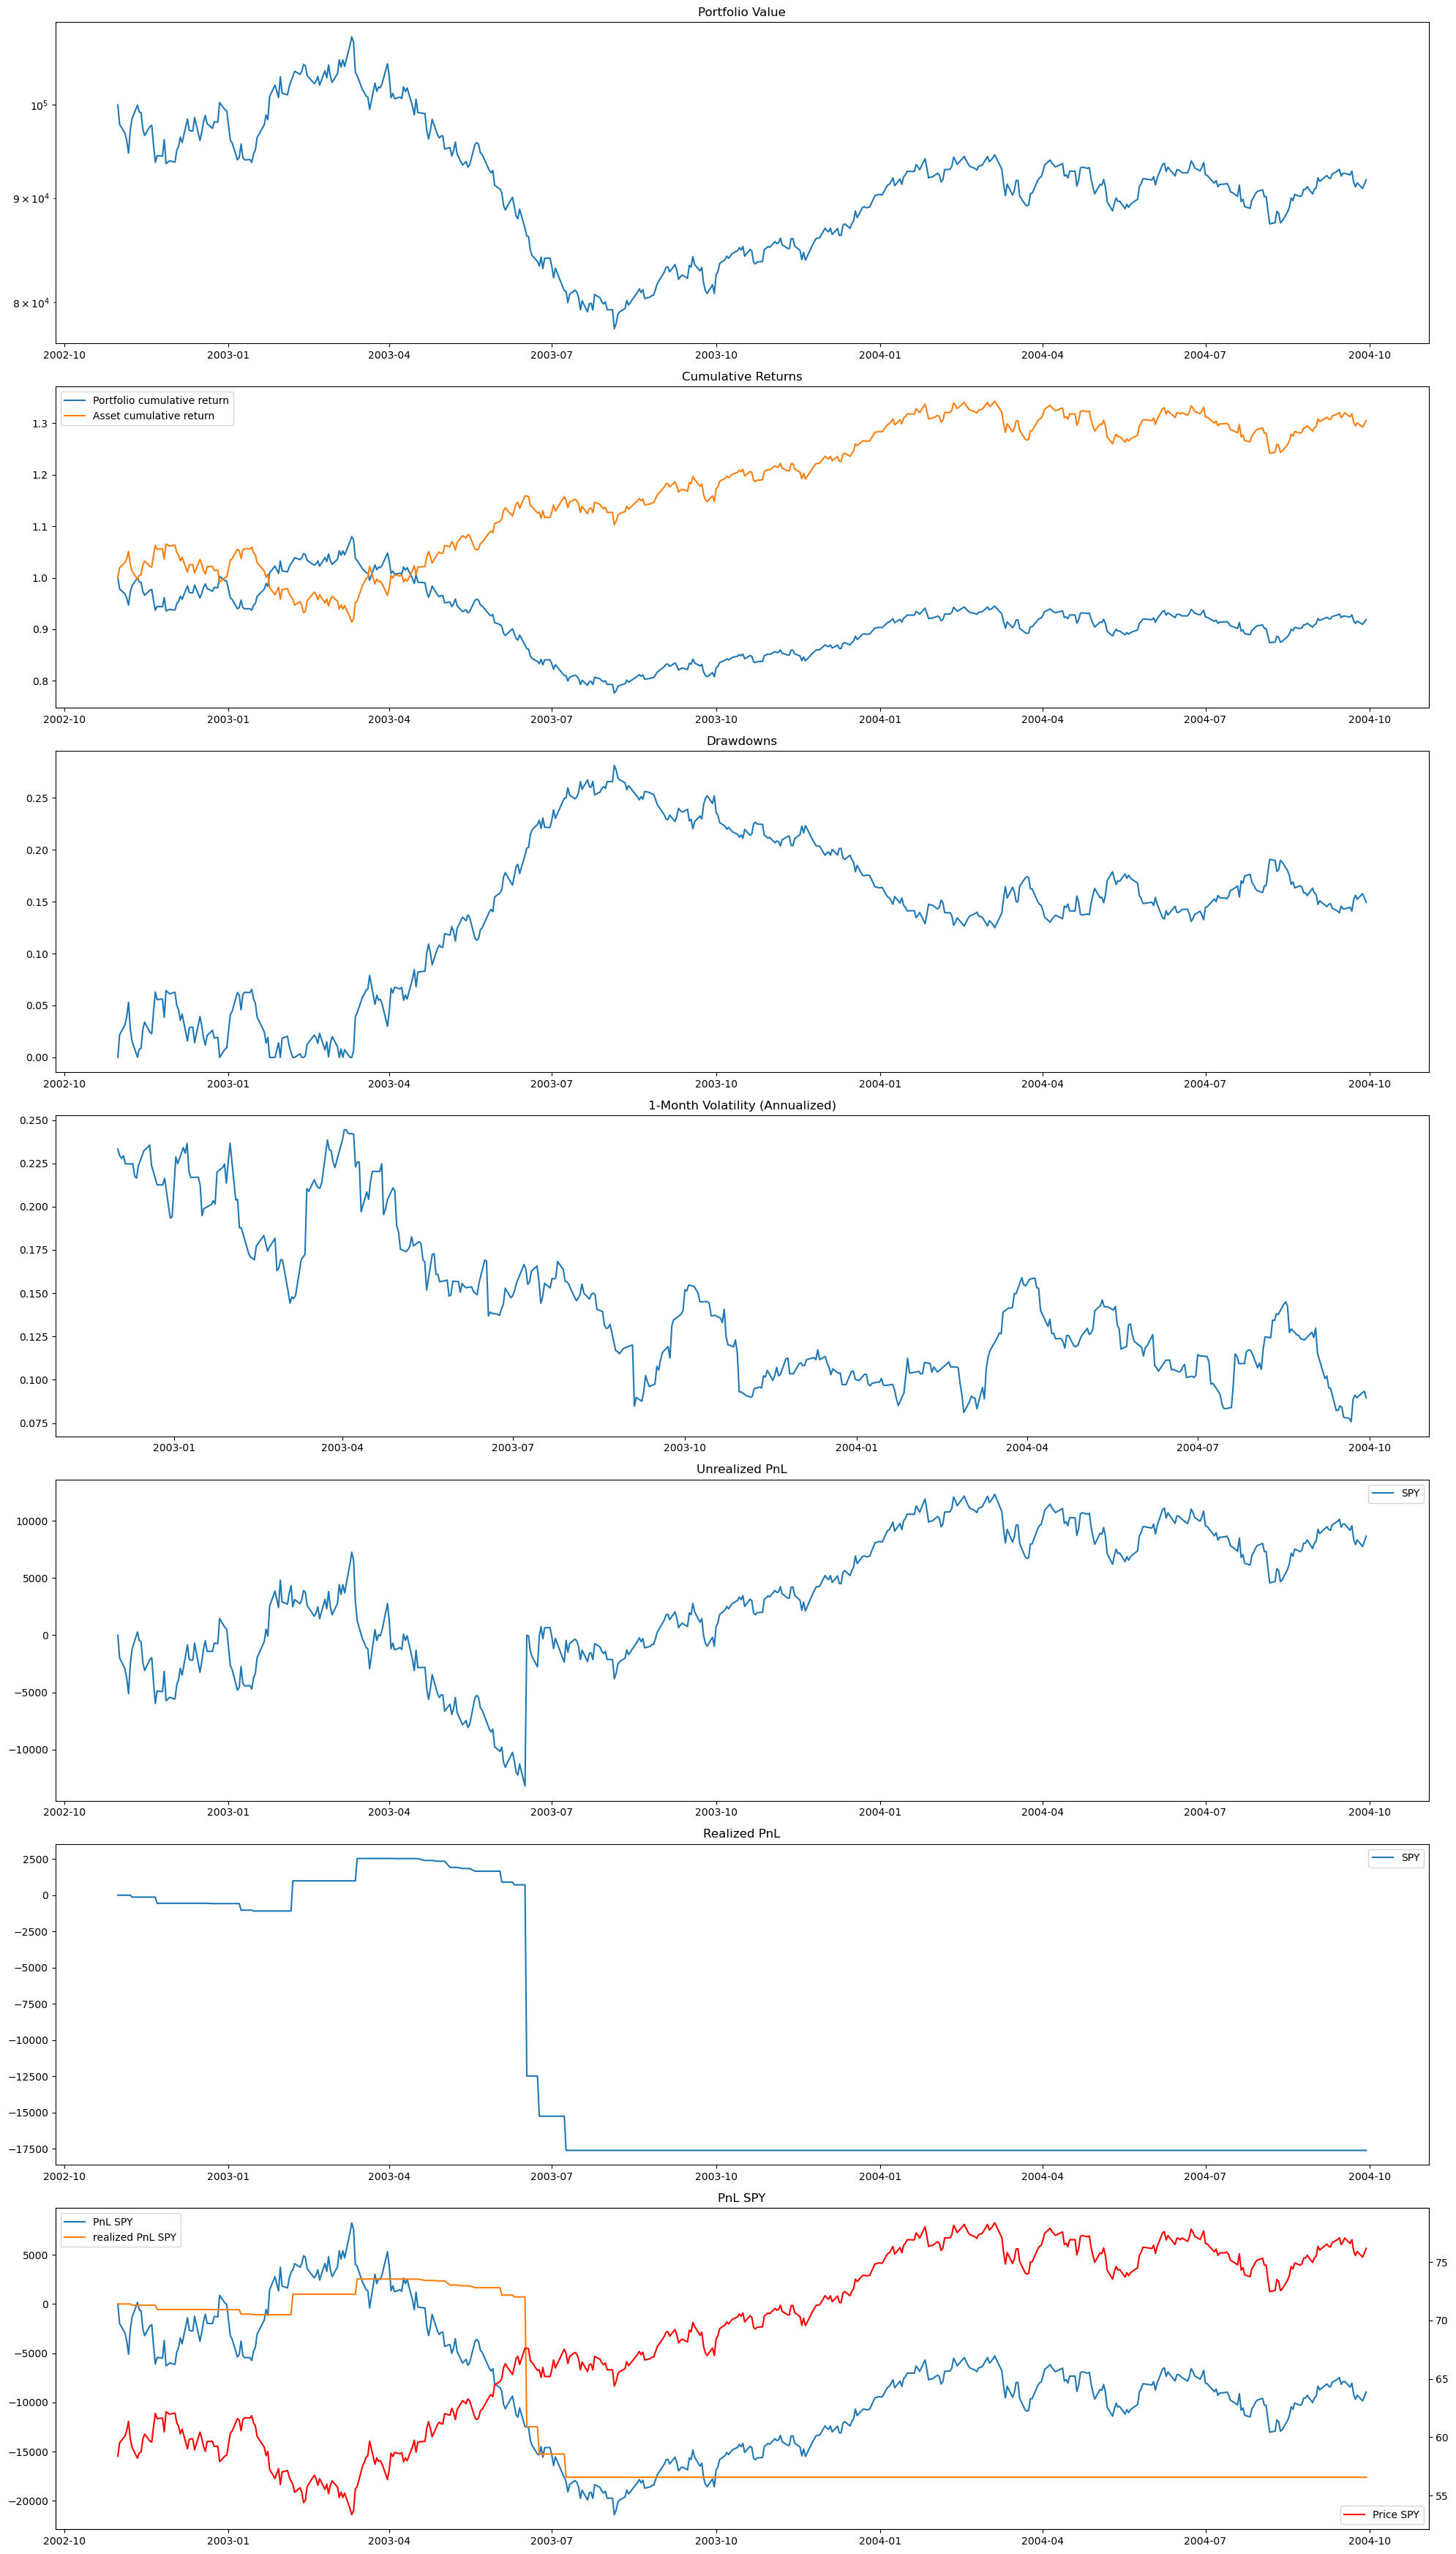

[I 2025-03-30 22:56:05,529] A new study created in memory with name: no-name-b98c8914-1c7a-447e-bfef-47fe02853b80


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 22:56:07,120] Trial 0 finished with value: 0.08391726441718061 and parameters: {'vol_threshold_1': 0.39290275999070623, 'vol_threshold_2': 0.6322899637165724}. Best is trial 0 with value: 0.08391726441718061.
[I 2025-03-30 22:56:07,123] Trial 1 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.9334876208733539, 'vol_threshold_2': 0.5364003914541386}. Best is trial 0 with value: 0.08391726441718061.
[I 2025-03-30 22:56:08,688] Trial 2 finished with value: 0.04540017097469917 and parameters: {'vol_threshold_1': 0.013955239188724322, 'vol_threshold_2': 0.8509261646077803}. Best is trial 0 with value: 0.08391726441718061.
[I 2025-03-30 22:56:08,691] Trial 3 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.51576952094943, 'vol_threshold_2': 0.005197907273086555}. Best is trial 0 with value: 0.08391726441718061.
[I 2025-03-30 22:56:10,783] Trial 4 finished with value: 0.08248003716374797 and parameters: {'vol_threshold_1': 0.2025750193063579, 'vol_t

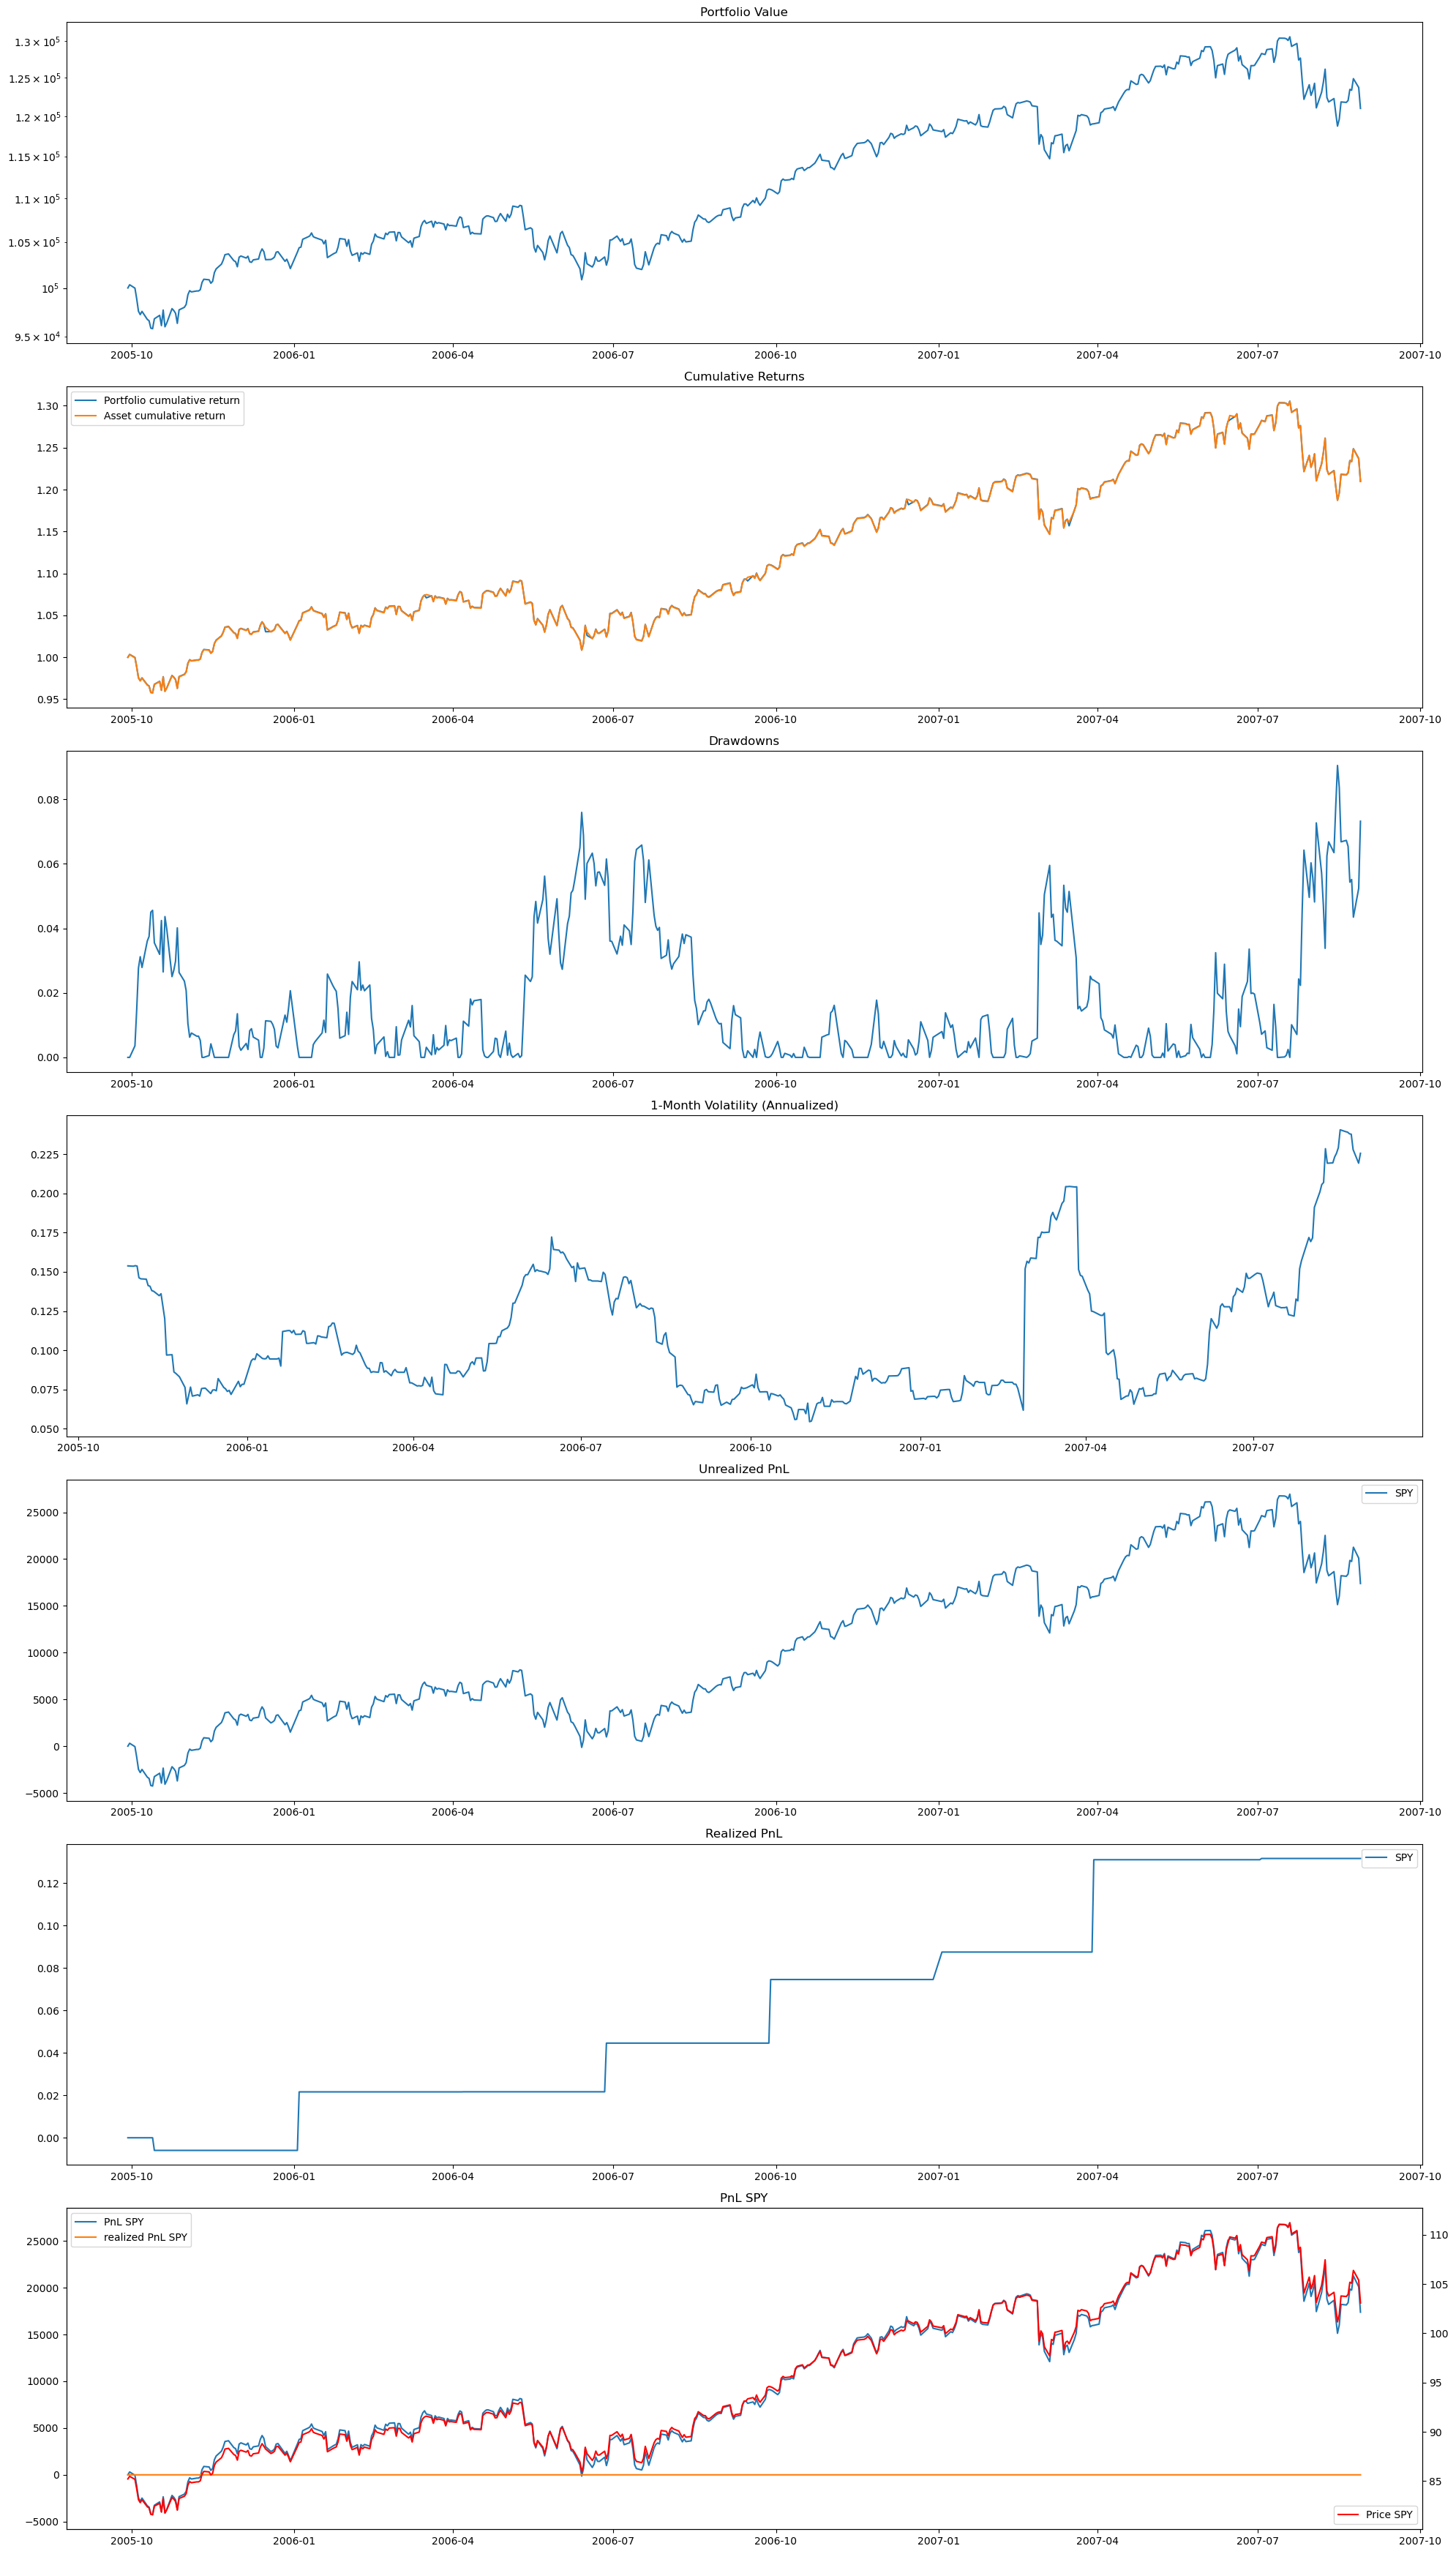

[I 2025-03-30 22:58:25,498] A new study created in memory with name: no-name-49b2ce21-12f5-4bd3-8c4b-c5ef88b7912e


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 22:58:25,507] Trial 0 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.6858232760849015, 'vol_threshold_2': 0.010834934749310854}. Best is trial 0 with value: -1.0.
[I 2025-03-30 22:58:25,509] Trial 1 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.9429764290450688, 'vol_threshold_2': 0.5111316813064064}. Best is trial 0 with value: -1.0.
[I 2025-03-30 22:58:27,505] Trial 2 finished with value: 0.09035068431125359 and parameters: {'vol_threshold_1': 0.20565538764974245, 'vol_threshold_2': 0.7101975728338602}. Best is trial 2 with value: 0.09035068431125359.
[I 2025-03-30 22:58:27,508] Trial 3 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.8932816475965314, 'vol_threshold_2': 0.13388207424323284}. Best is trial 2 with value: 0.09035068431125359.
[I 2025-03-30 22:58:27,510] Trial 4 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.9903130391218026, 'vol_threshold_2': 0.9177950351905068}. Best is trial 2 with valu

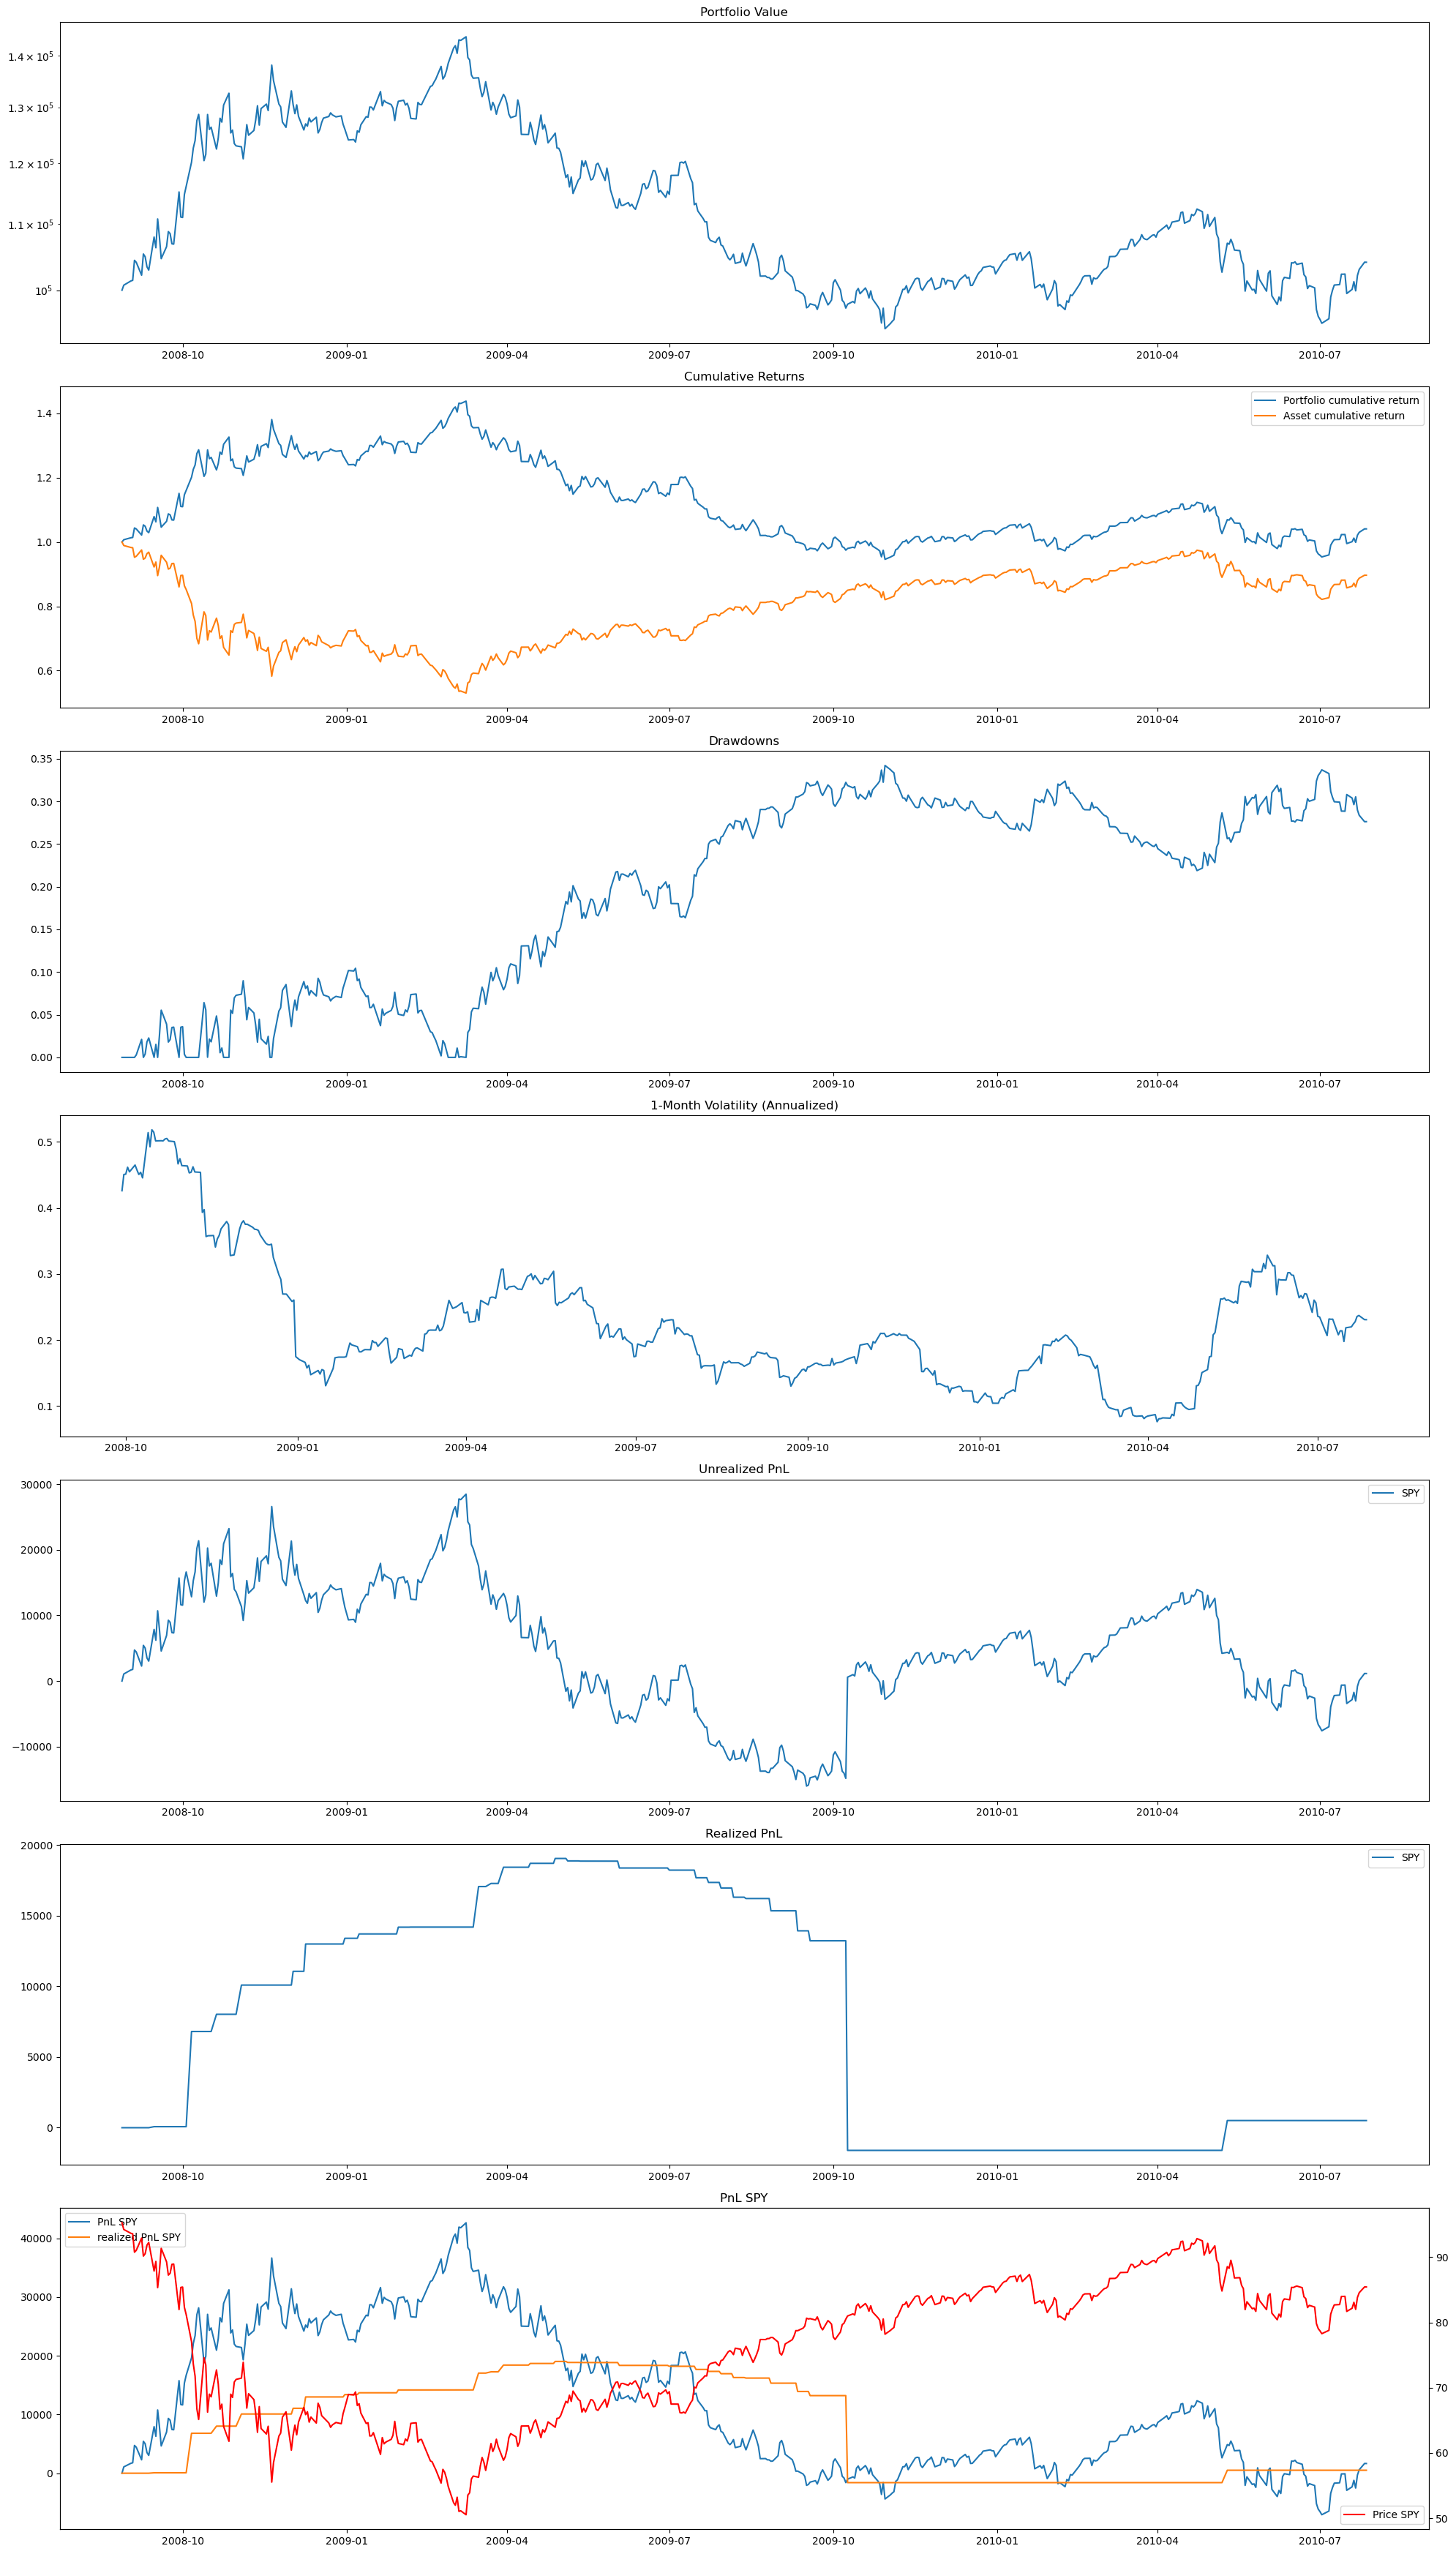

[I 2025-03-30 23:00:40,921] A new study created in memory with name: no-name-804fe159-a654-4d84-92cd-6cae52b4d15d


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 23:00:40,930] Trial 0 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.8732608529479609, 'vol_threshold_2': 0.36160765698611286}. Best is trial 0 with value: -1.0.
[I 2025-03-30 23:00:40,931] Trial 1 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.6782437994107512, 'vol_threshold_2': 0.1265984298570514}. Best is trial 0 with value: -1.0.
[I 2025-03-30 23:00:43,379] Trial 2 finished with value: 0.09516933396681981 and parameters: {'vol_threshold_1': 0.3188485889401894, 'vol_threshold_2': 0.429203601674609}. Best is trial 2 with value: 0.09516933396681981.
[I 2025-03-30 23:00:45,784] Trial 3 finished with value: 0.08795893955257816 and parameters: {'vol_threshold_1': 0.6127904669937948, 'vol_threshold_2': 0.9012573534950964}. Best is trial 2 with value: 0.09516933396681981.
[I 2025-03-30 23:00:48,118] Trial 4 finished with value: 0.08263823198978537 and parameters: {'vol_threshold_1': 0.741621355753552, 'vol_threshold_2': 0.9897488521361674}. 

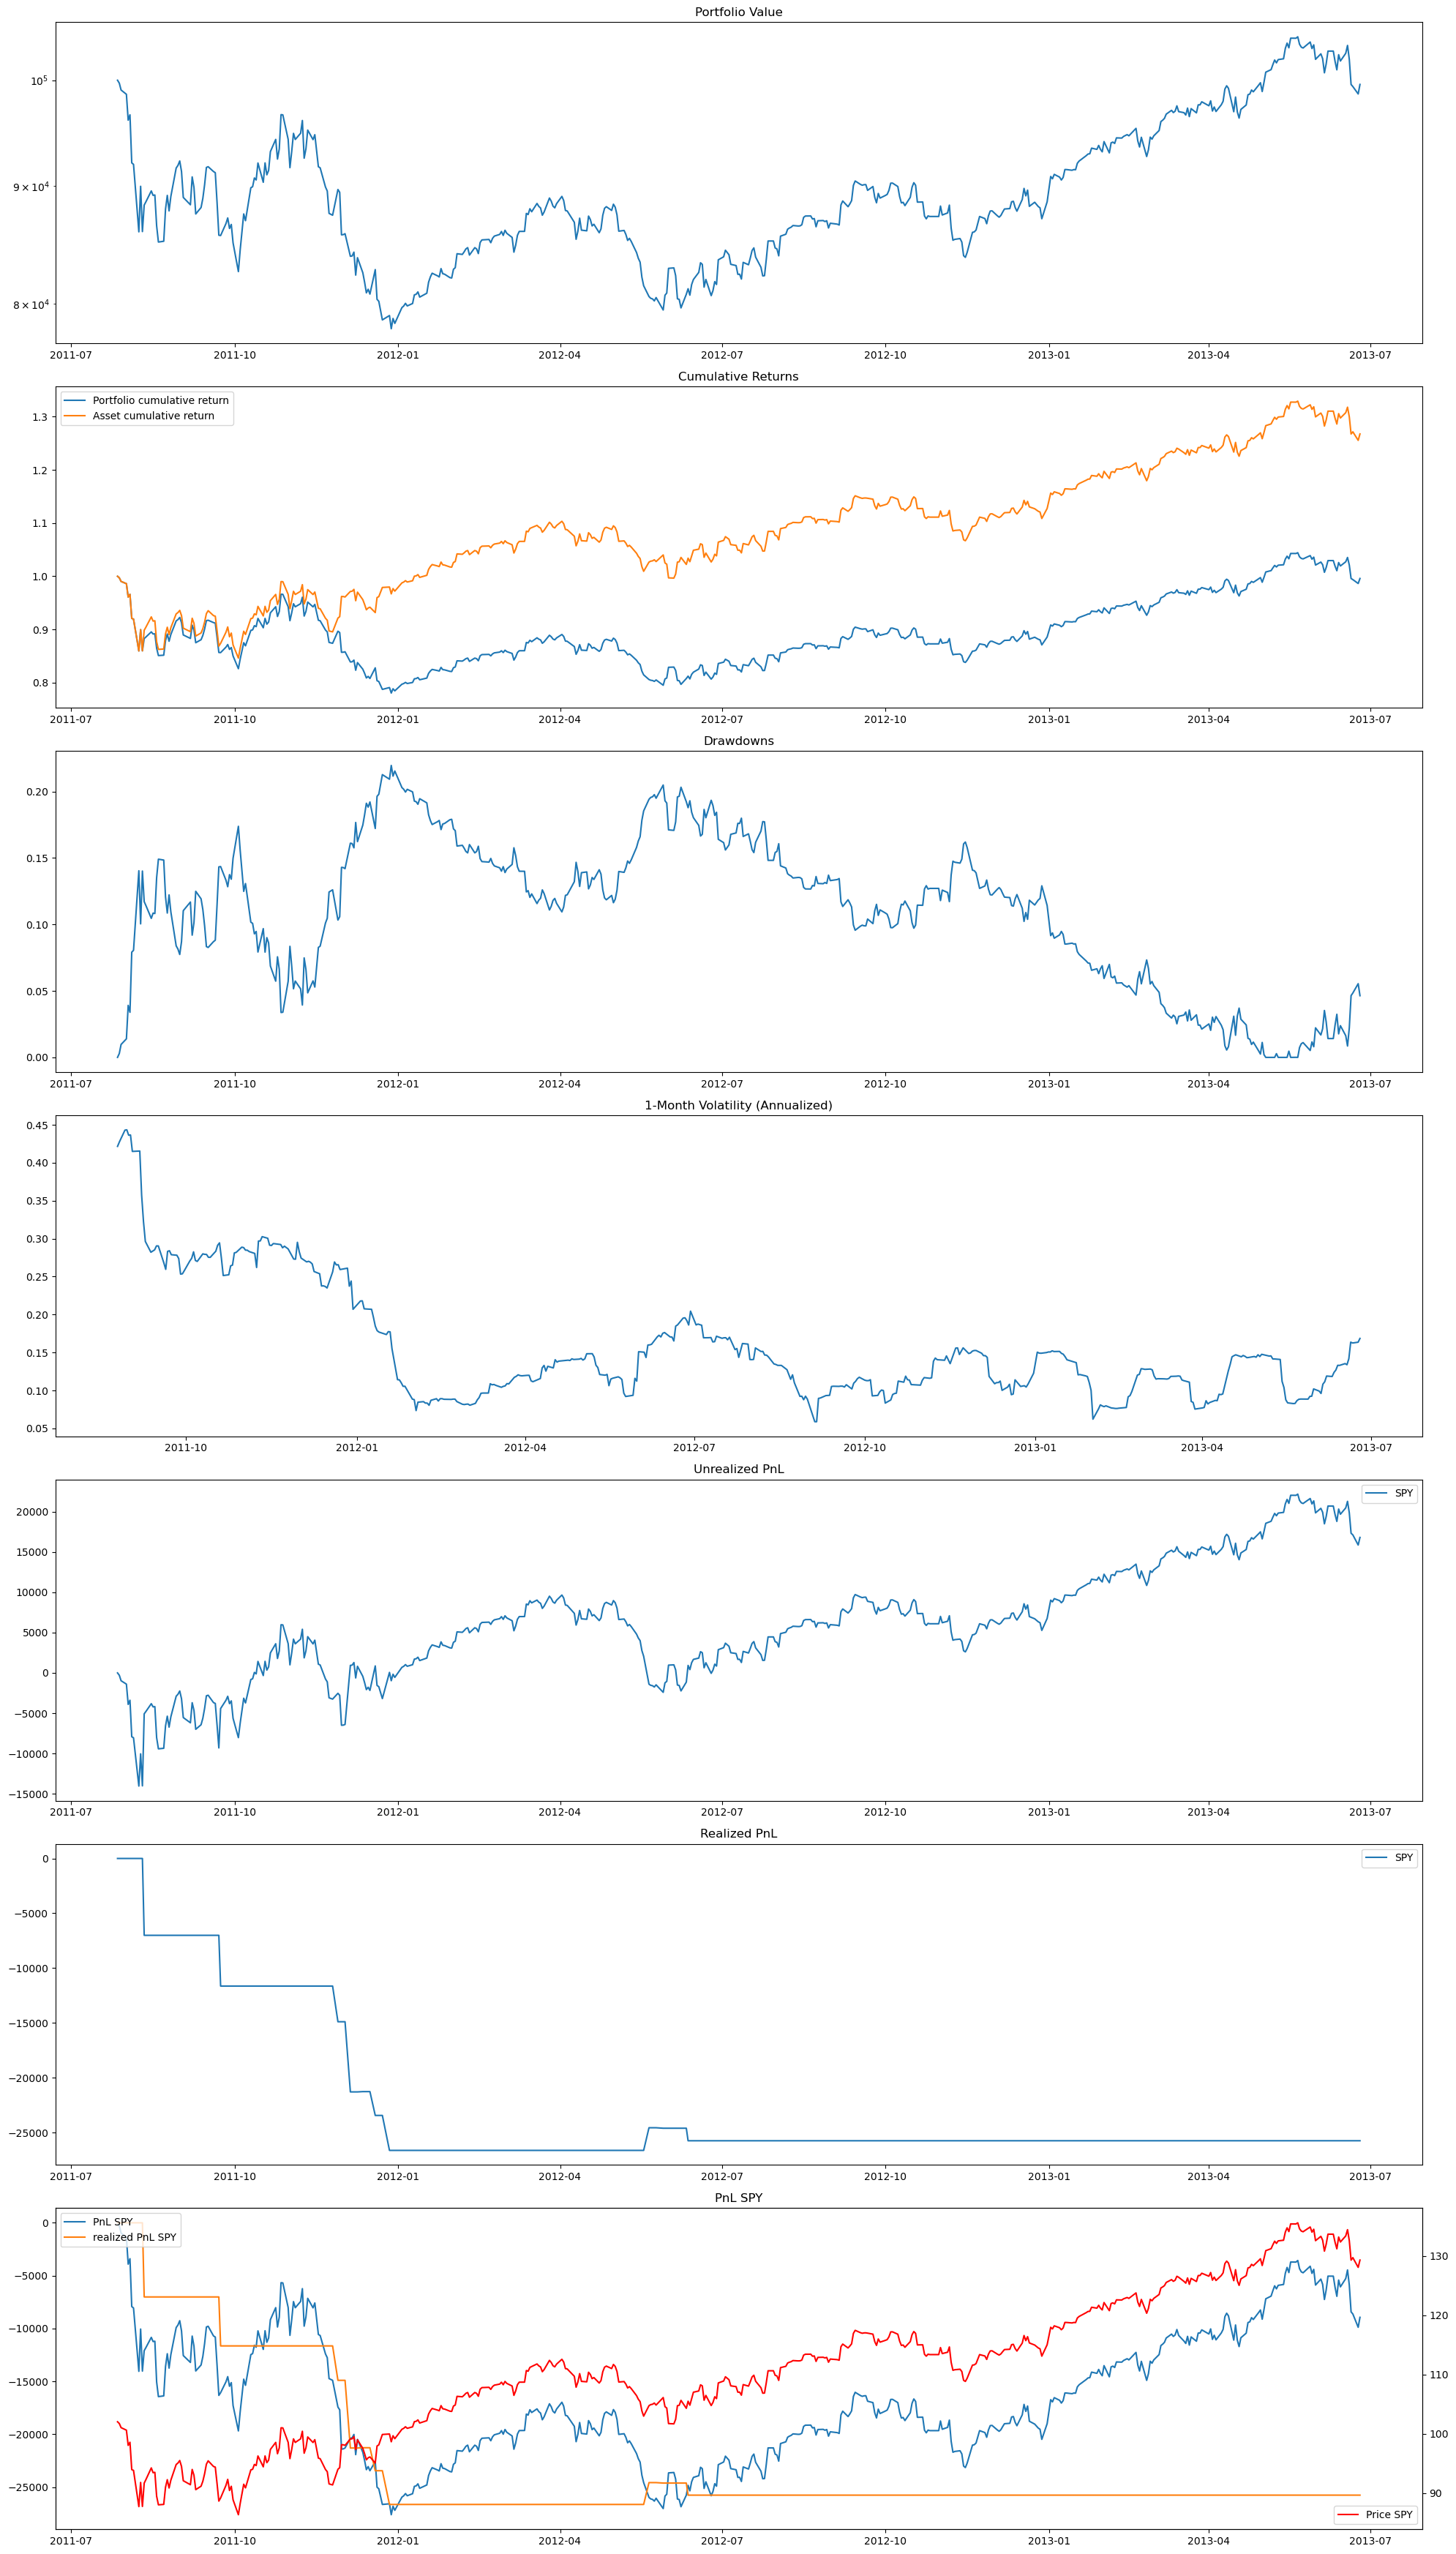

[I 2025-03-30 23:03:45,901] A new study created in memory with name: no-name-0956e3b1-b7f5-4f8a-9572-e56c0d05b880


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 23:03:45,910] Trial 0 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.9837154473993533, 'vol_threshold_2': 0.6108374021481636}. Best is trial 0 with value: -1.0.
[I 2025-03-30 23:03:45,911] Trial 1 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.9662074910810687, 'vol_threshold_2': 0.3083512755513984}. Best is trial 0 with value: -1.0.
[I 2025-03-30 23:03:48,748] Trial 2 finished with value: 0.0411908610059184 and parameters: {'vol_threshold_1': 0.07771310490556071, 'vol_threshold_2': 0.2157691915443013}. Best is trial 2 with value: 0.0411908610059184.
[I 2025-03-30 23:03:48,751] Trial 3 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.45852132338833207, 'vol_threshold_2': 0.3702511674788699}. Best is trial 2 with value: 0.0411908610059184.
[I 2025-03-30 23:03:51,533] Trial 4 finished with value: 0.043796137270129876 and parameters: {'vol_threshold_1': 0.06102430148808846, 'vol_threshold_2': 0.3615633576631636}. Best is trial

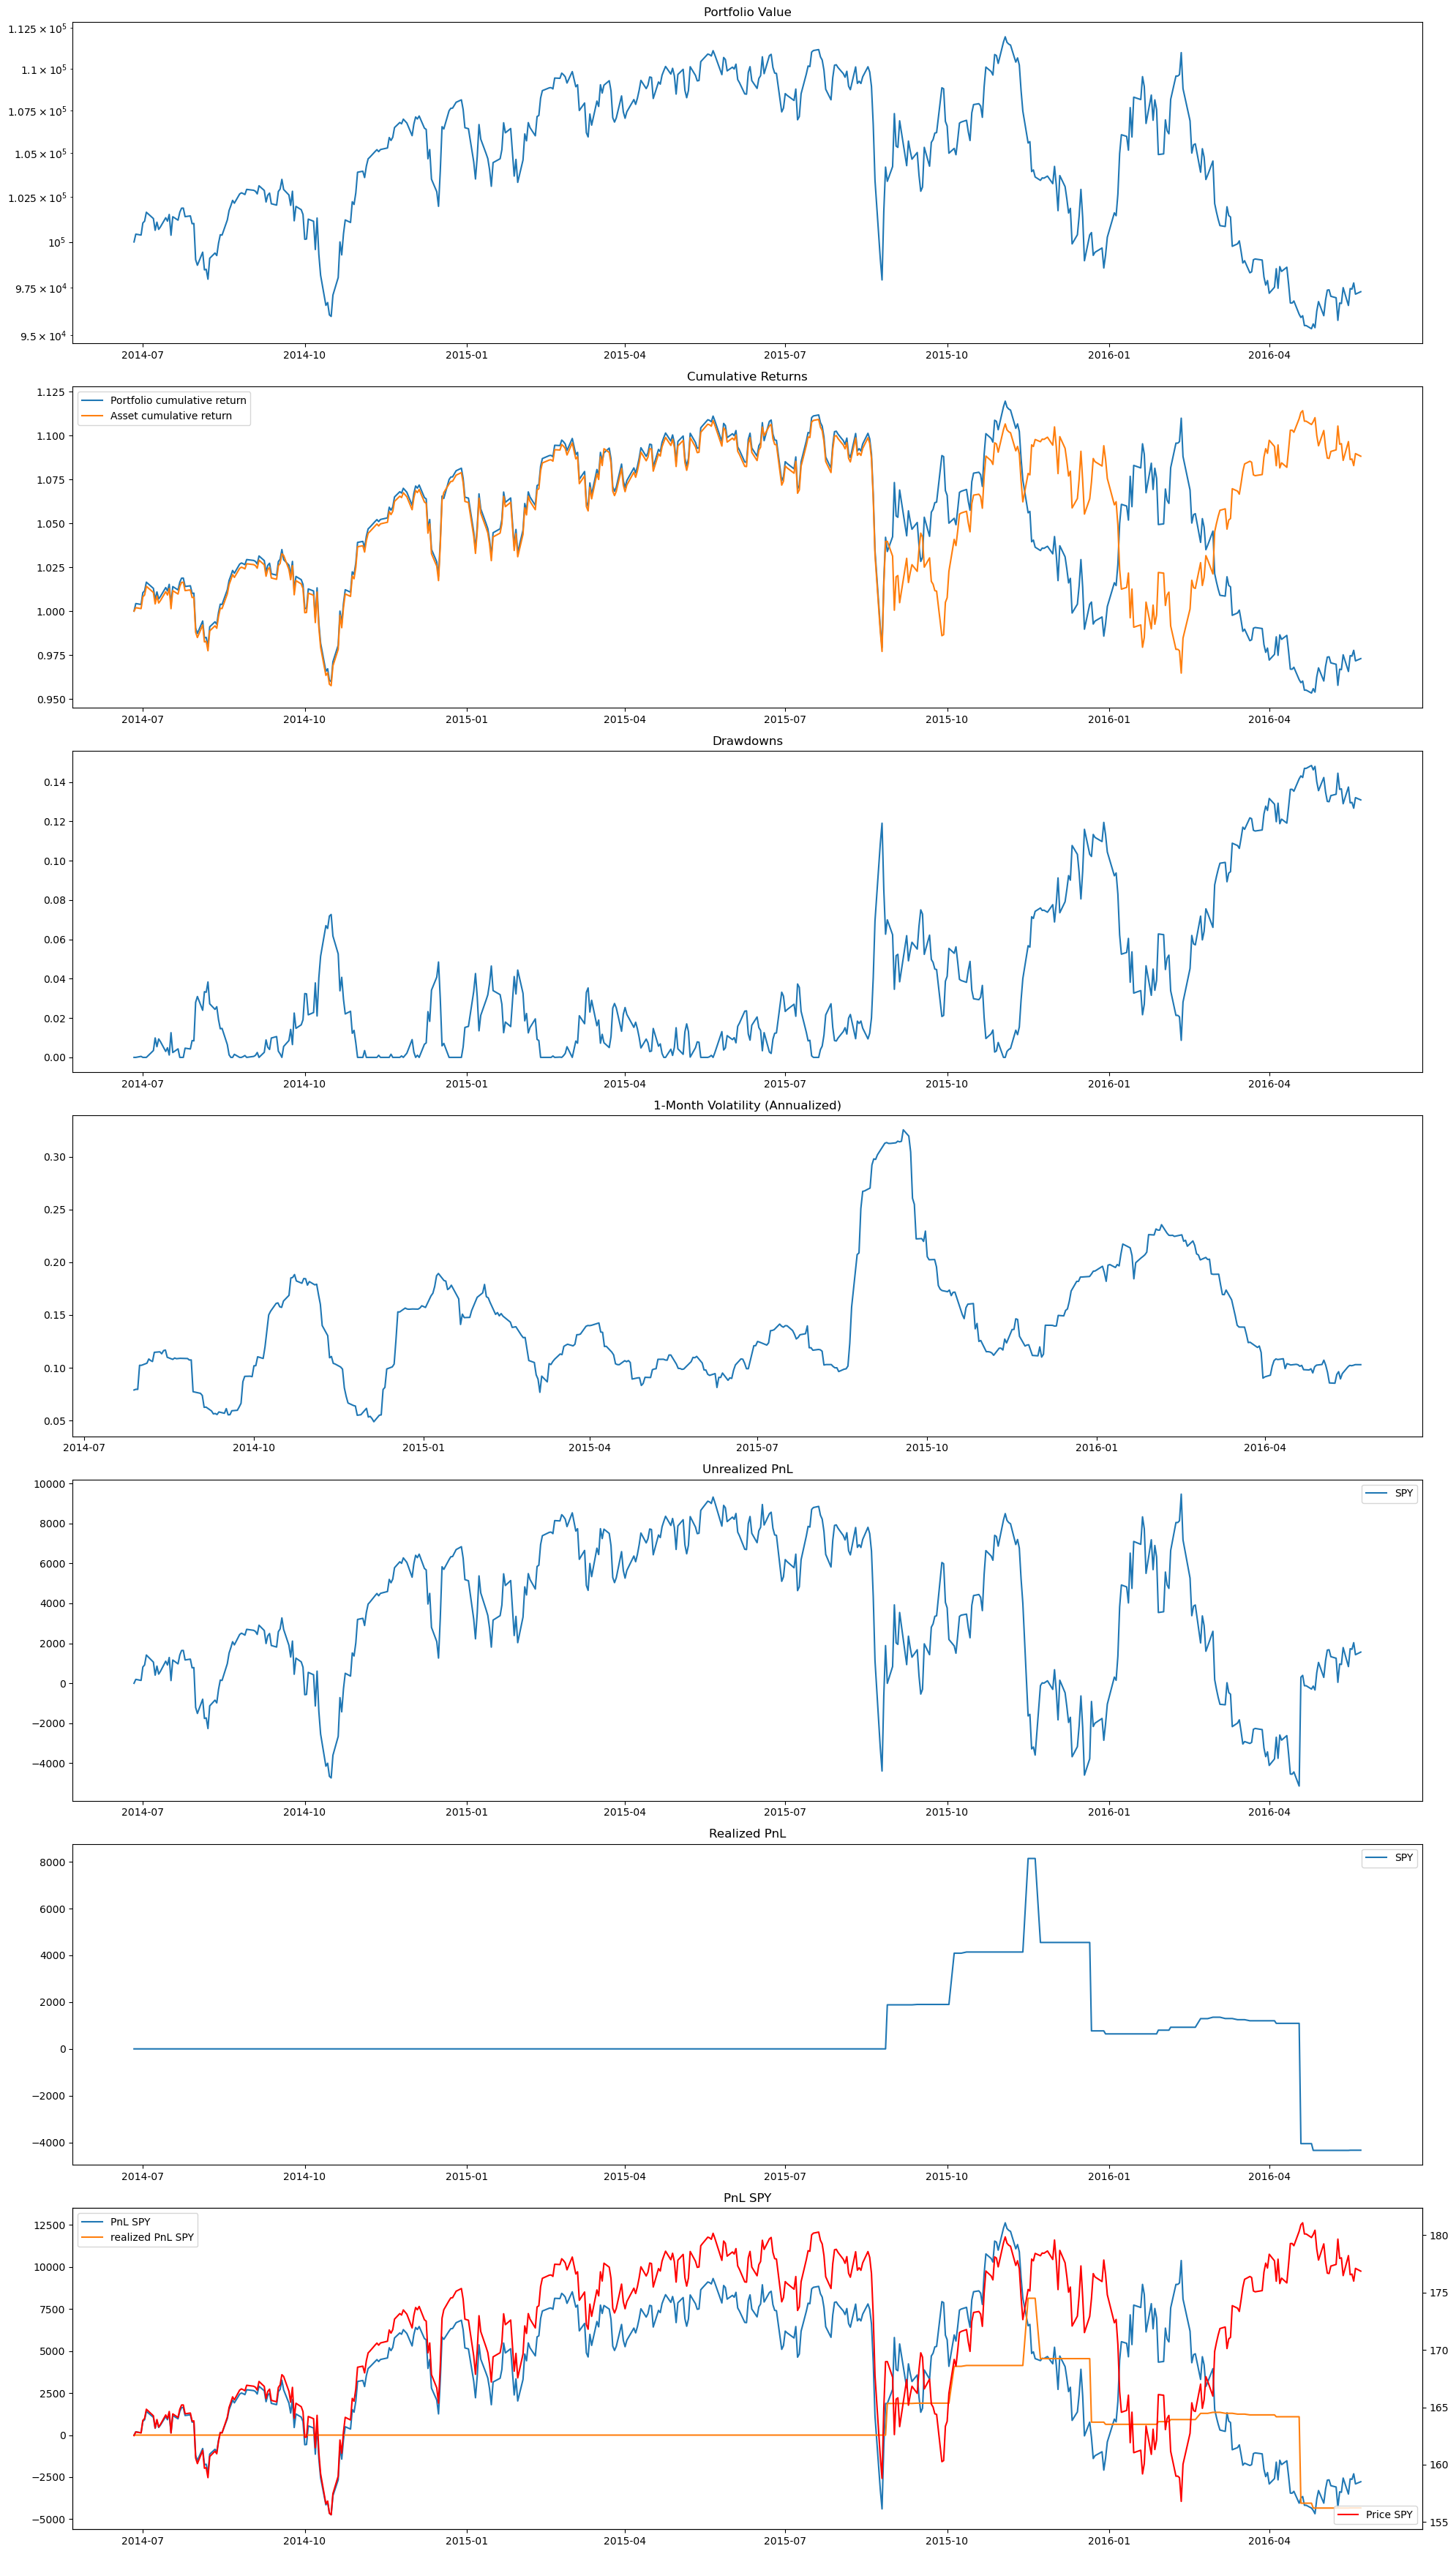

[I 2025-03-30 23:07:57,554] A new study created in memory with name: no-name-734cc315-4271-45a0-8eca-785c40d1111a


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 23:08:00,688] Trial 0 finished with value: 0.07975424270845721 and parameters: {'vol_threshold_1': 0.7434609363278579, 'vol_threshold_2': 0.9600188234958259}. Best is trial 0 with value: 0.07975424270845721.
[I 2025-03-30 23:08:00,691] Trial 1 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.5119665468645145, 'vol_threshold_2': 0.46749398653721697}. Best is trial 0 with value: 0.07975424270845721.
[I 2025-03-30 23:08:00,692] Trial 2 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.8133517200537337, 'vol_threshold_2': 0.5518428928543676}. Best is trial 0 with value: 0.07975424270845721.
[I 2025-03-30 23:08:03,781] Trial 3 finished with value: 0.07975424270845721 and parameters: {'vol_threshold_1': 0.9244754386577666, 'vol_threshold_2': 0.9848197678872495}. Best is trial 0 with value: 0.07975424270845721.
[I 2025-03-30 23:08:03,783] Trial 4 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.5956596259825054, 'vol_threshold_2': 0.57

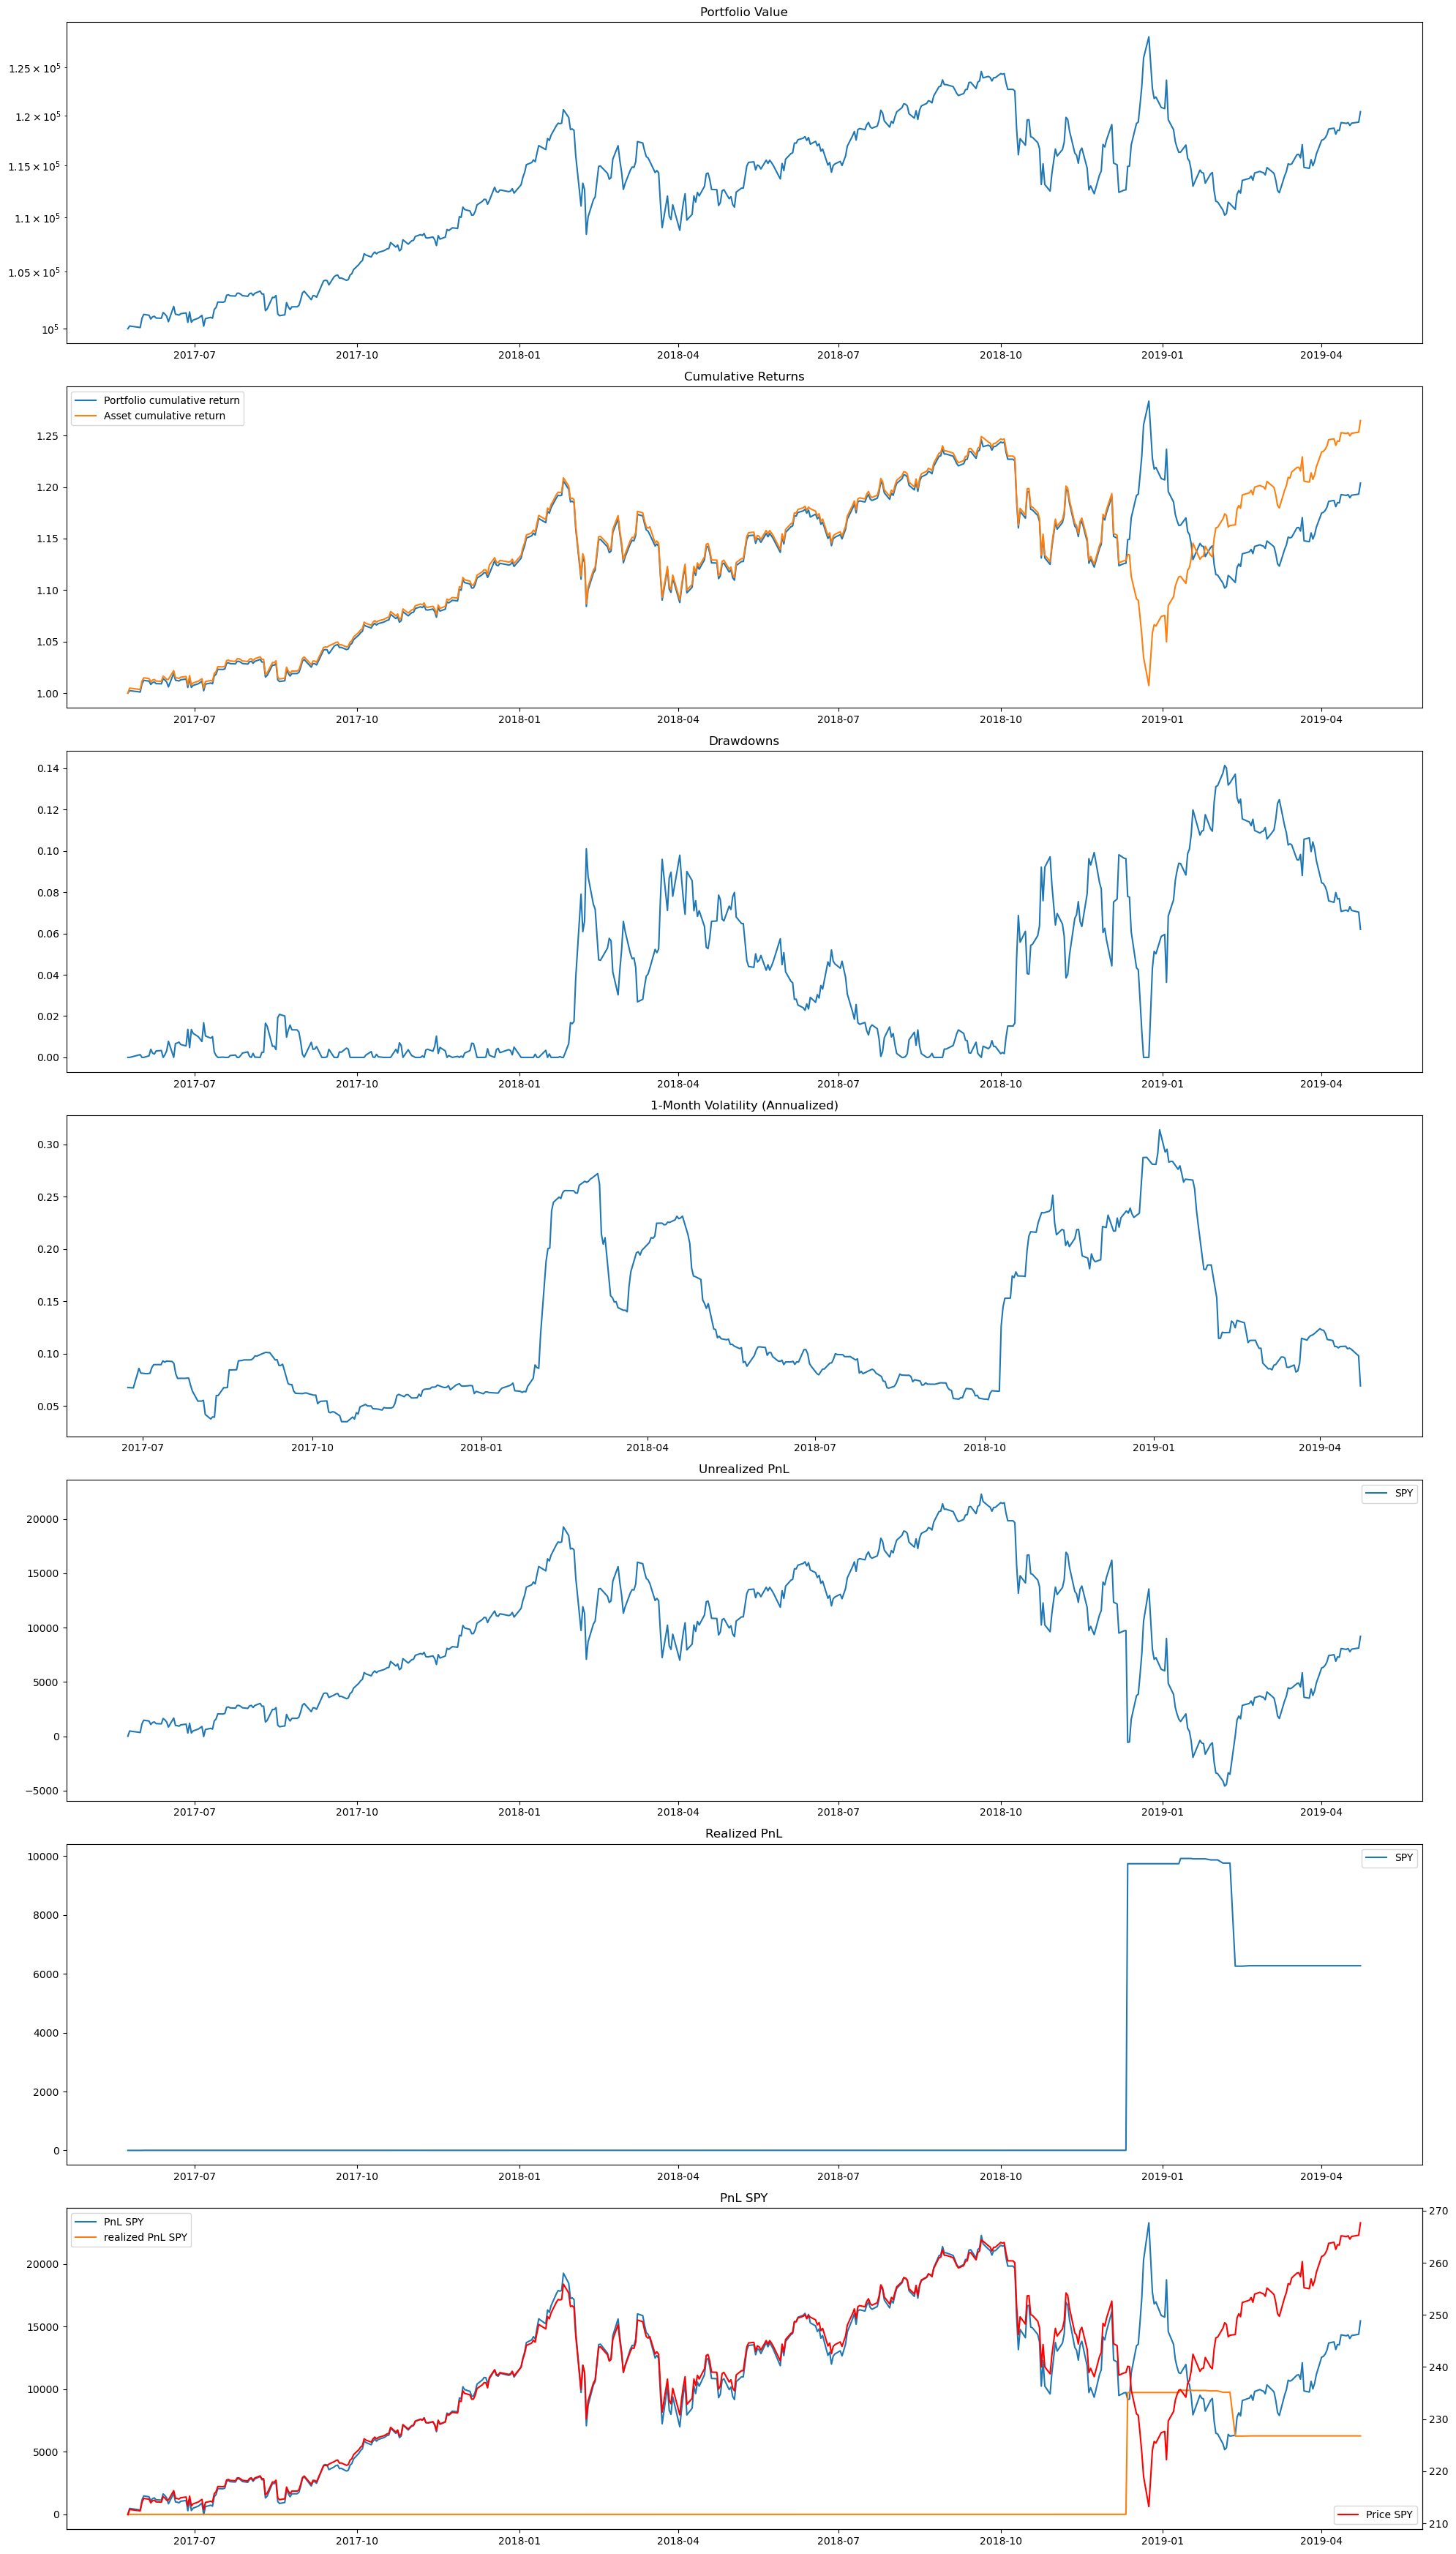

[I 2025-03-30 23:12:10,364] A new study created in memory with name: no-name-aff045bb-e718-43dd-96f5-509416507f49


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 23:12:10,373] Trial 0 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.8999358478252474, 'vol_threshold_2': 0.27989104627693606}. Best is trial 0 with value: -1.0.
[I 2025-03-30 23:12:10,374] Trial 1 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.8633962017323983, 'vol_threshold_2': 0.10710624866025609}. Best is trial 0 with value: -1.0.
[I 2025-03-30 23:12:10,376] Trial 2 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.21314960621064505, 'vol_threshold_2': 0.024717561397802346}. Best is trial 0 with value: -1.0.
[I 2025-03-30 23:12:14,000] Trial 3 finished with value: 0.08508385719847955 and parameters: {'vol_threshold_1': 0.45139186885688054, 'vol_threshold_2': 0.7261533082538402}. Best is trial 3 with value: 0.08508385719847955.
[I 2025-03-30 23:12:14,002] Trial 4 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.8881218394136584, 'vol_threshold_2': 0.7679178090849285}. Best is trial 3 with value: 0.08508385

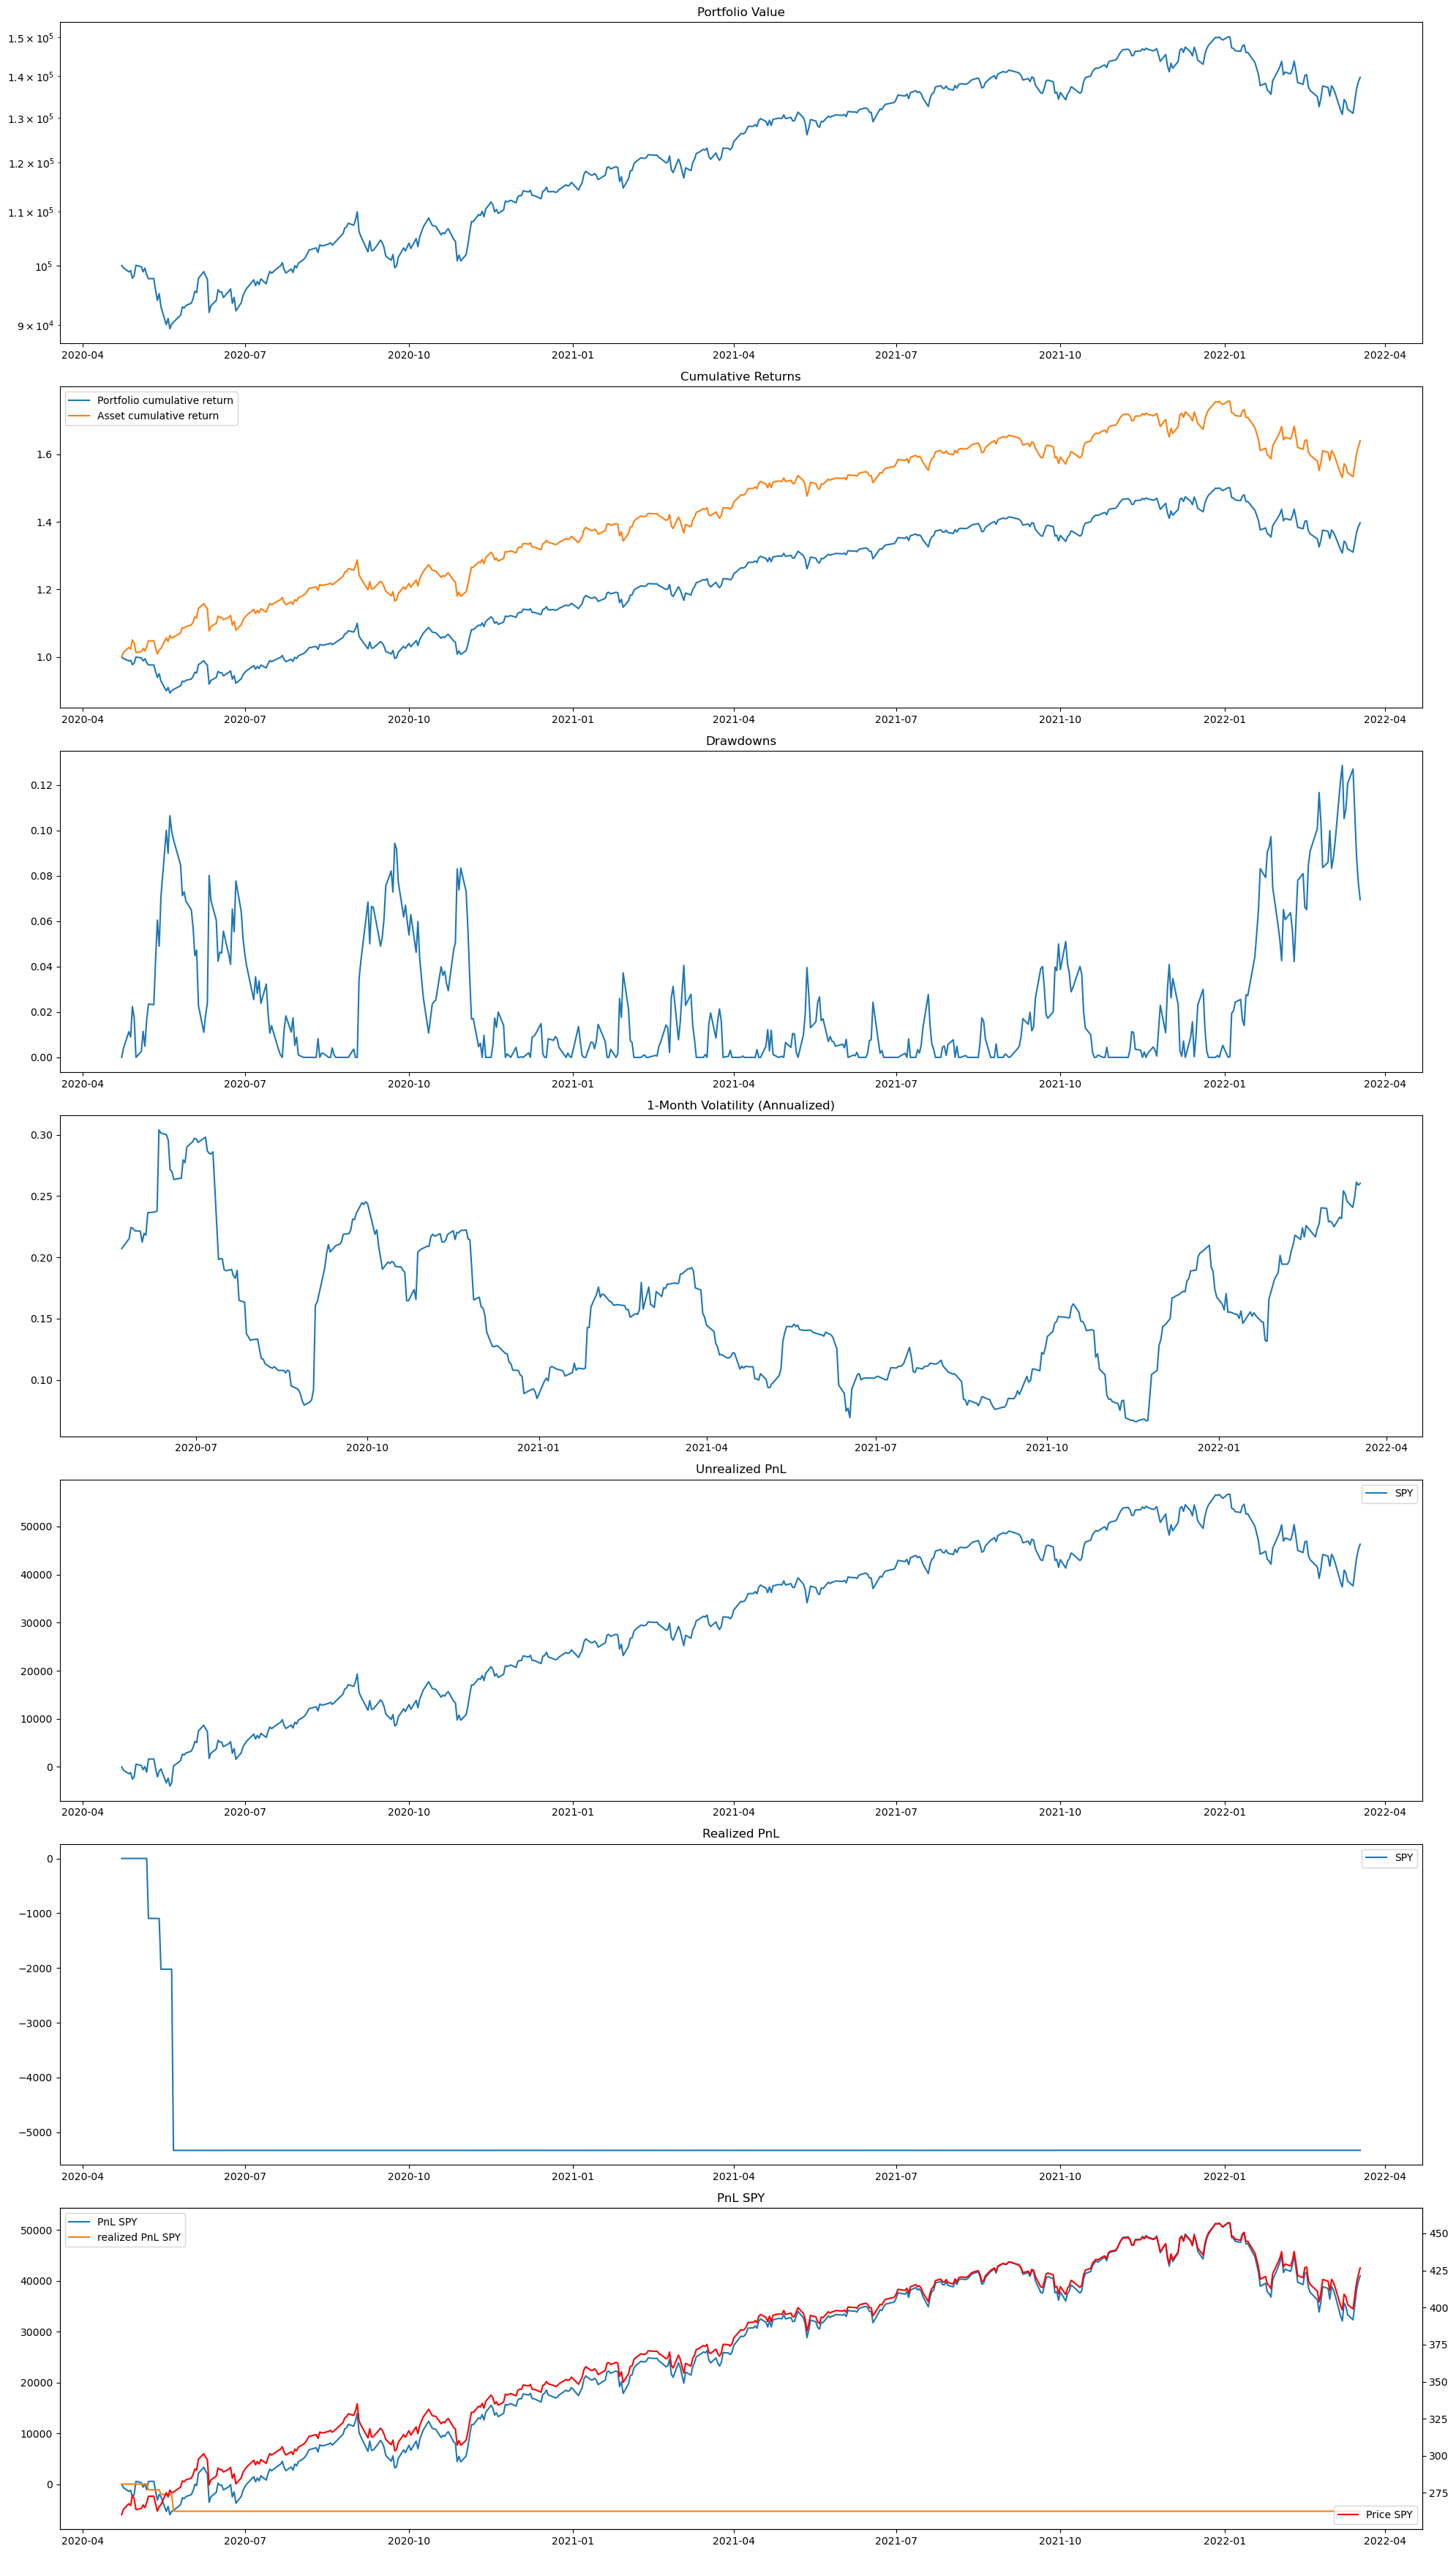

[I 2025-03-30 23:17:11,342] A new study created in memory with name: no-name-3ec3e0a8-8e37-44f0-8b51-ce8594d2cc46


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-30 23:17:11,350] Trial 0 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.7435900332217347, 'vol_threshold_2': 0.0915280327422171}. Best is trial 0 with value: -1.0.
[I 2025-03-30 23:17:15,243] Trial 1 finished with value: 0.07899829205380748 and parameters: {'vol_threshold_1': 0.43189941520084996, 'vol_threshold_2': 0.7815479260516544}. Best is trial 1 with value: 0.07899829205380748.
[I 2025-03-30 23:17:15,246] Trial 2 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.9288976515790136, 'vol_threshold_2': 0.7087223696720681}. Best is trial 1 with value: 0.07899829205380748.
[I 2025-03-30 23:17:15,247] Trial 3 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.8069836160054693, 'vol_threshold_2': 0.006975390923157798}. Best is trial 1 with value: 0.07899829205380748.
[I 2025-03-30 23:17:15,249] Trial 4 finished with value: -1.0 and parameters: {'vol_threshold_1': 0.9835320133064085, 'vol_threshold_2': 0.03246839850643746}. Best is tr

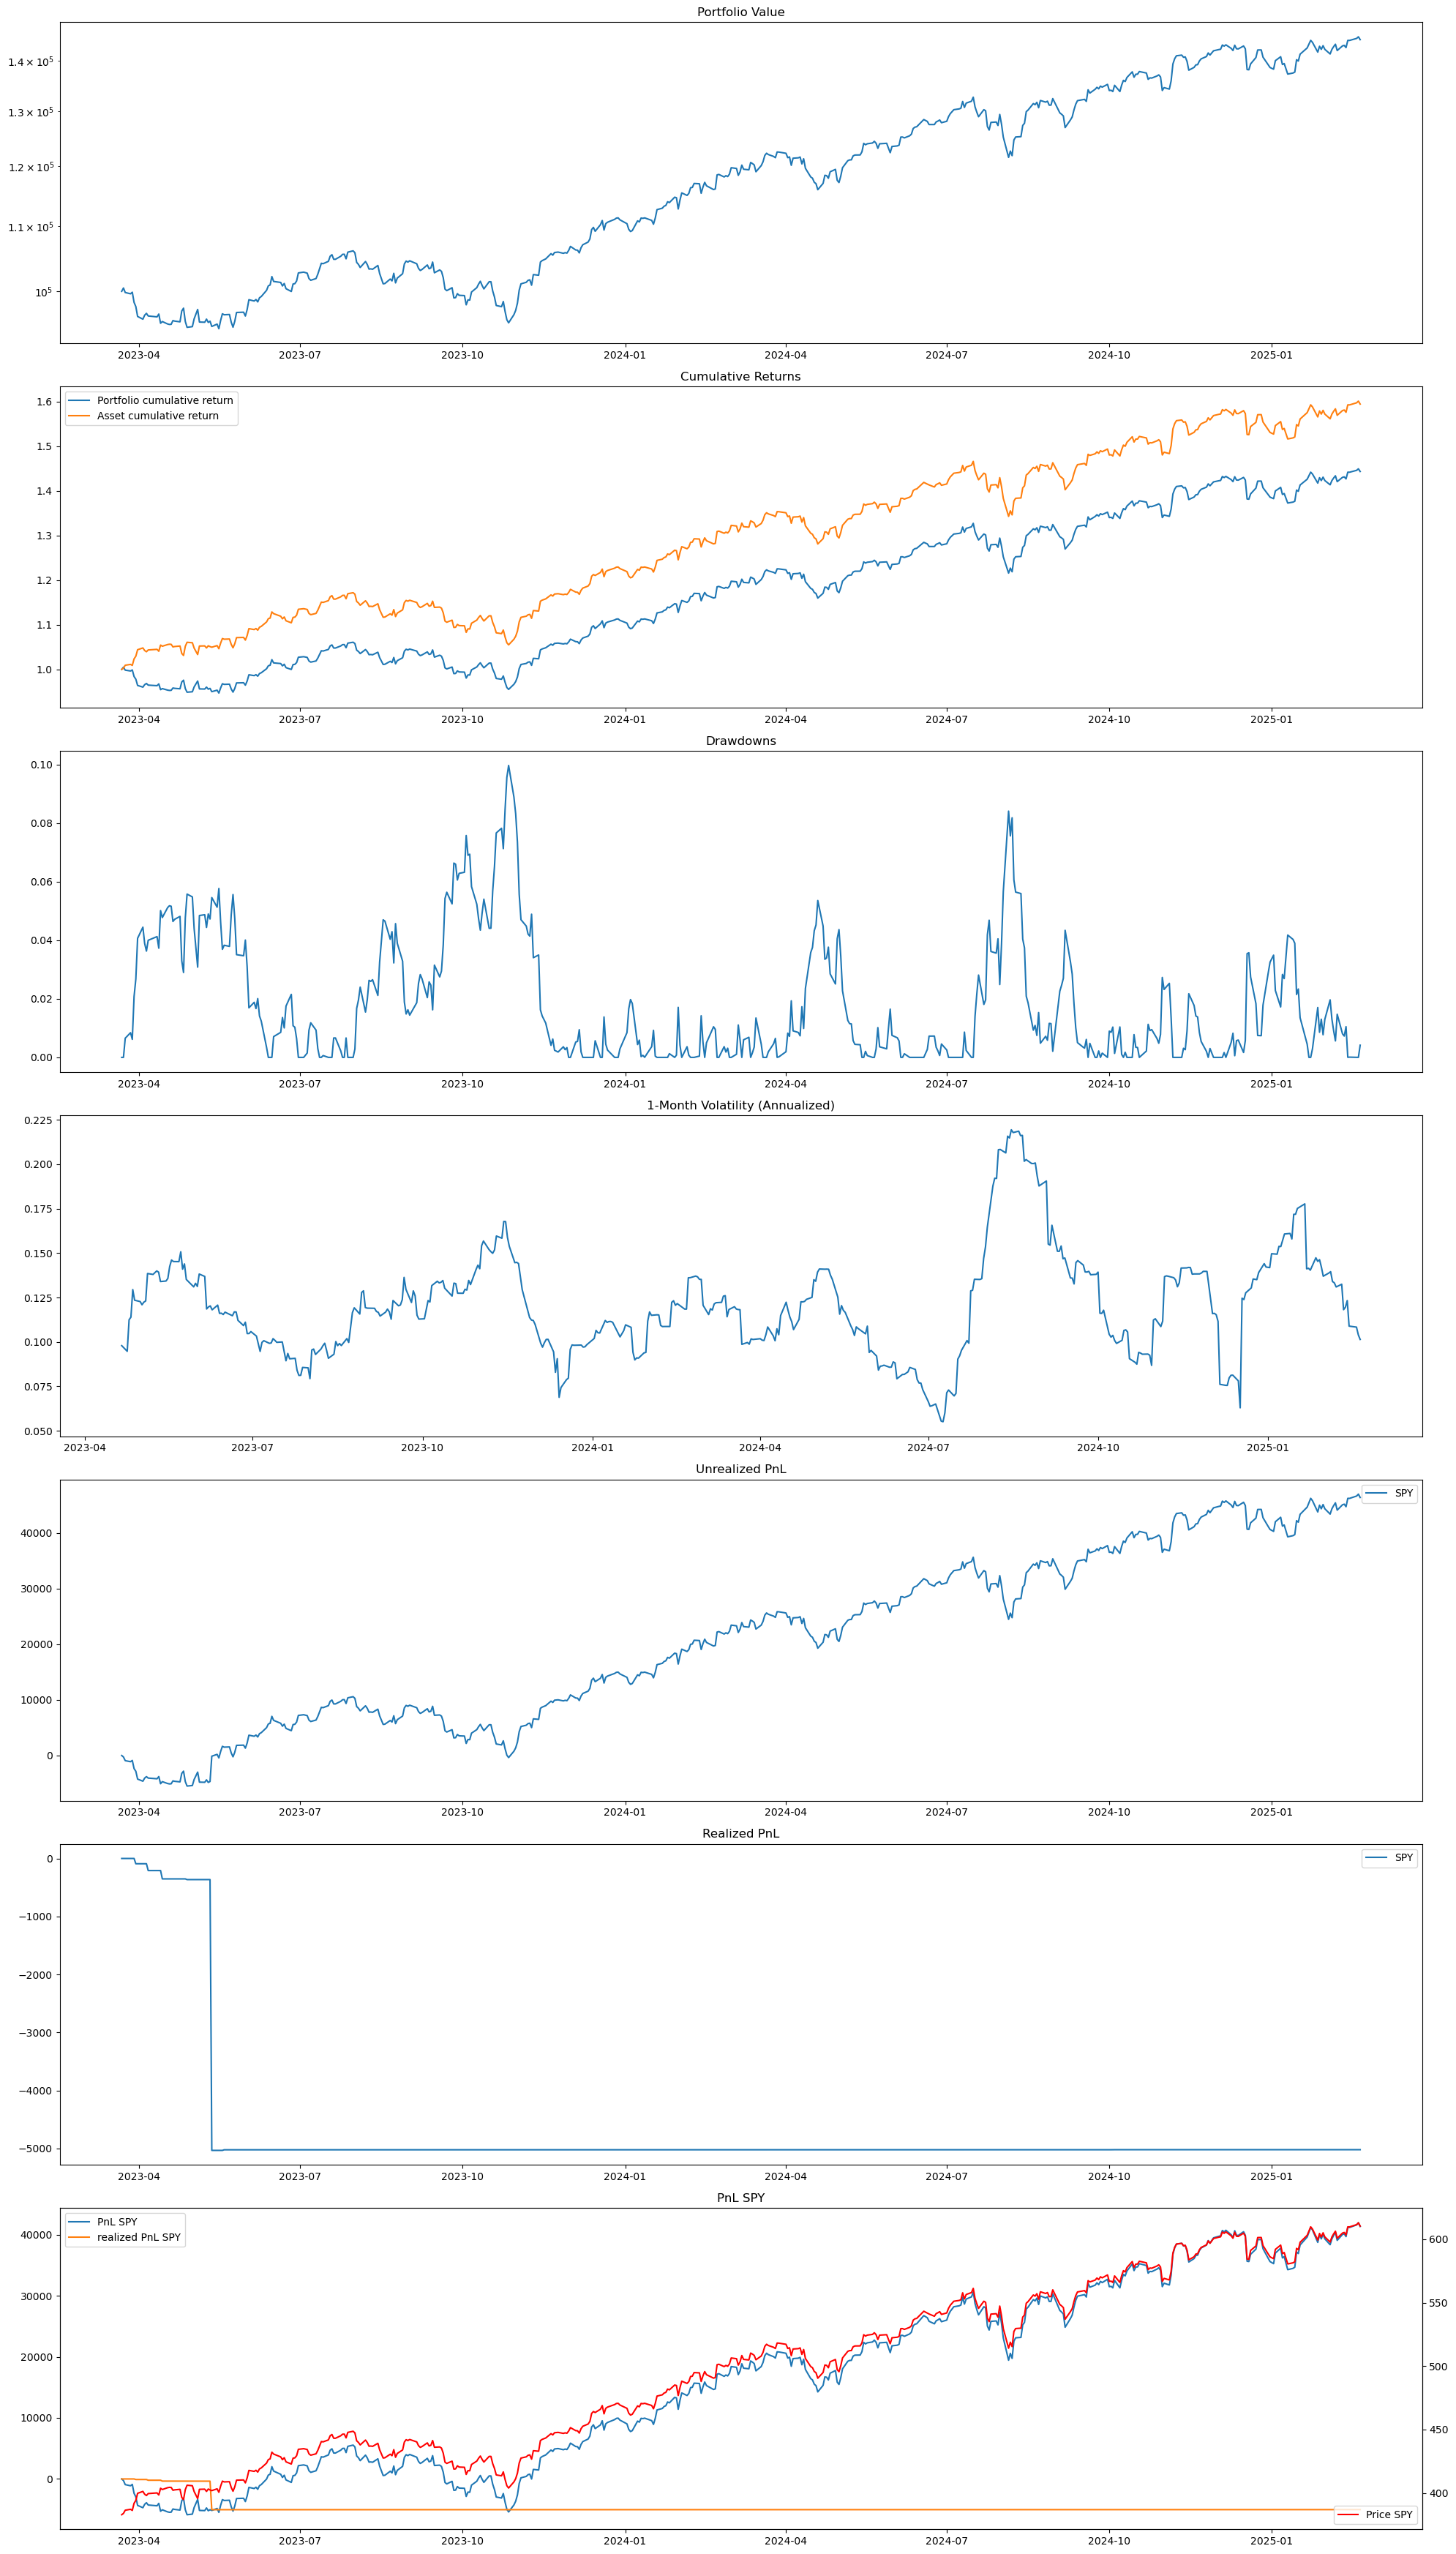

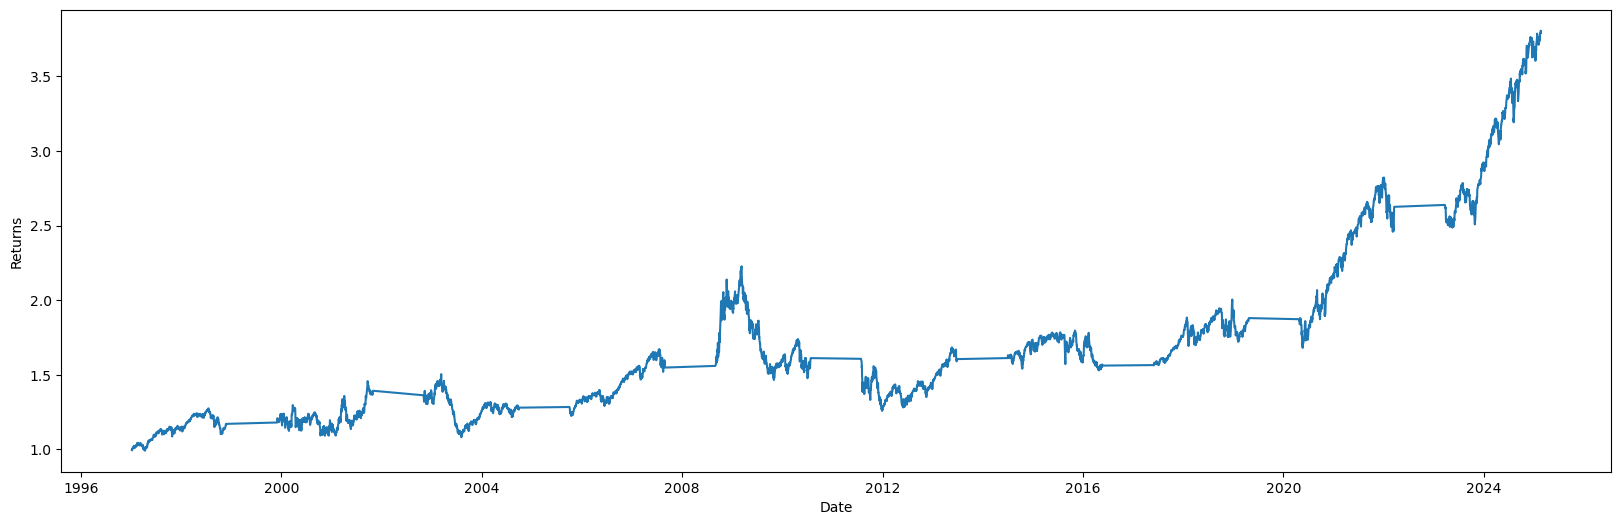

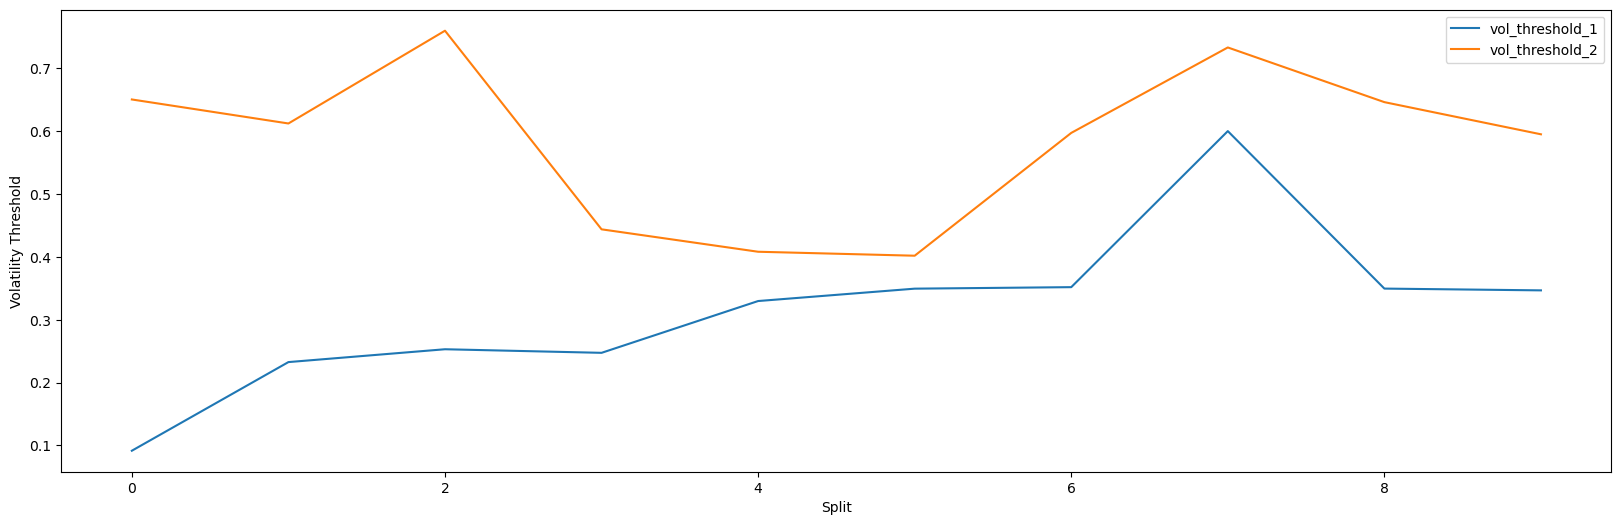

In [45]:
import optuna
# use optuna to optimize the parameters of the strategy

df_combined_results = pd.DataFrame()



for i in tqdm(range(n_splits)):
    df_train = data[i]['train'].copy()
    df_test = data[i]['test'].copy()

    def objective(trial):
        # Define the parameters to optimize
        rebalance_period = 5
        vol_threshold_1 = trial.suggest_float('vol_threshold_1', 0.0, 1.0)
        vol_threshold_2 = trial.suggest_float('vol_threshold_2', 0.0, 1.0)

        if vol_threshold_1 >= vol_threshold_2:
            return -1
        
        

        # Initialize backtester
        btr = BackTester({'SPY': df_train})
        # Add strategy
        btr.add_strategy(
            VolReductionTrendStrategy, 
            tickers=['SPY'], 
            price_data={'SPY': df_train}, 
            rebalance_period=rebalance_period,
            lookback_period=252,
            df_vol=df_train, 
            vol_threshold_1=vol_threshold_1,
            vol_threshold_2=vol_threshold_2,
        )
        results = btr.backtest()
        return results['cagr']

    # Create a study and optimize the objective function
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # Print the best parameters
    print(f"Best parameters: {study.best_params}")
    print(f"Best sharpe ratio: {study.best_value}")

    data[i]['optuna_best_params'] = study.best_params
    

    # Initialize backtester
    btr = BackTester({'SPY': df_test})
    # Add strategy
    btr.add_strategy(
        VolReductionTrendStrategy, 
        tickers=['SPY'], 
        price_data={'SPY': df_test}, 
        rebalance_period=5,
        lookback_period=252,
        df_vol=df_test, 
        vol_threshold_1=study.best_params['vol_threshold_1'],
        vol_threshold_2=study.best_params['vol_threshold_2'],
    )
    results = btr.backtest()

    btr.plot_results()

    df_returns = results['returns']

    df_combined_results = pd.concat([df_combined_results, df_returns])
    # break

df_combined_results['returns'] = df_combined_results['returns'] + 1
df_combined_results['returns_cum'] = df_combined_results['returns'].cumprod()

plt.figure(figsize=(20, 6))
plt.plot(df_combined_results.index, df_combined_results['returns_cum'])
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

plt.figure(figsize=(20, 6))
plt.plot([data[i]['optuna_best_params']['vol_threshold_1'] for i in range(n_splits)], label='vol_threshold_1')
plt.plot([data[i]['optuna_best_params']['vol_threshold_2'] for i in range(n_splits)], label='vol_threshold_2')
plt.legend()
plt.xlabel('Split')
plt.ylabel('Volatility Threshold')
plt.show()

    

# END